In [1]:
import pandas as pd
import pandas_ta_classic as ta
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau


import numpy as np

import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, precision_score, recall_score, f1_score, matthews_corrcoef


In [2]:
master_df = pd.read_parquet("stocknet-dataset/master_df_with_sector_features.parquet")
master_df.reset_index(drop=True, inplace=True)

print("shape before sector features:", master_df.shape)
print("Columns in master_df:", master_df.columns)

shape before sector features: (104220, 48)
Columns in master_df: Index(['date', 'open', 'high', 'low', 'close', 'adj close', 'volume', 'ticker',
       'text', 'sentiment', 'emotion_anger', 'emotion_disgust', 'emotion_fear',
       'emotion_joy', 'emotion_neutral', 'emotion_sadness', 'emotion_surprize',
       'stance_positive', 'stance_negative', 'sector', 'company_name',
       'EMA_12', 'EMA_26', 'EMA_50', 'MACD_12_26_9', 'MACDh_12_26_9',
       'MACDs_12_26_9', 'RSI_14', 'STOCHRSIk_14_14_3_3', 'STOCHRSId_14_14_3_3',
       'ATRr_14', 'BB_upper', 'BB_middle', 'BB_lower', 'OBV',
       'sector_open_mean', 'sector_high_mean', 'sector_low_mean',
       'sector_close_mean', 'sector_volume_mean', 'sector_ret_1d',
       'sector_ret_5d', 'sector_ret_20d', 'sector_range', 'sector_vol_20d',
       'market_close', 'sector_rel_strength', 'sector_dispersion_1d'],
      dtype='object')


In [3]:
master_df['date'] = pd.to_datetime(master_df['date'])
master_df = master_df.sort_values(by=['ticker', 'date']).reset_index(drop=True)

In [4]:
H_META = 1 # 1-day ahead meta target
INITIAL_TRAINING_DAYS = 1000

In [5]:
master_df = master_df.sort_values(by=['ticker', 'date'])

master_df['ret_1d_meta'] = (
    master_df.groupby('ticker')['close']
    .pct_change(periods=-H_META)
)

In [6]:
master_df['up_1d_meta'] = (master_df['ret_1d_meta'] > 0).astype(int)

master_df['has_meta_target'] = master_df['ret_1d_meta'].notna().astype(int)

In [7]:
unique_dates = sorted(master_df['date'].unique())
meta_train_cutoff = unique_dates[INITIAL_TRAINING_DAYS-1]
print("Meta-training up to:", meta_train_cutoff)

Meta-training up to: 2016-11-02 00:00:00


In [ ]:
base_feature_columns = [
    'open','high','low', 'volume',
    'roll_ret_1d', 'roll_ret_5d',
                   
    'sector_open_mean', 'sector_high_mean', 'sector_low_mean', 'sector_volume_mean',
    
    'EMA_12', 'EMA_26', 'EMA_50', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
    'RSI_14', 'ATRr_14', 'STOCHRSIk_14_14_3_3', 'STOCHRSId_14_14_3_3',
    'BB_upper', 'BB_middle', 'BB_lower', 'OBV',
    
    'sector_ret_1d', 'sector_ret_5d', 'sector_ret_20d', 
    # 'sector_ret_60d',
    'sector_vol_20d', 'sector_dispersion_1d',
    'sector_rel_strength',
    
    # 'EMA_12_sector', 'EMA_26_sector', 'EMA_50_sector', 'MACD_12_26_9_sector', 'MACDh_12_26_9_sector', 
    # 'MACDs_12_26_9_sector', 'RSI_14_sector', 'sector_BB_upper', 'sector_BB_middle','sector_BB_lower'
]

In [9]:
tickers = master_df['ticker'].unique()
len(tickers), tickers[:5]


(88, array(['AAPL', 'ABB', 'ABBV', 'AEP', 'AGFS'], dtype=object))

In [10]:
def split_ticker_meta(df_ticker, cutoff_date):
    df_ticker = df_ticker.sort_values('date')
    # remove rows without target
    df_ticker = df_ticker[~df_ticker['ret_1d_meta'].isna()].copy()
    if df_ticker.empty:
        return None, None
    
    train_mask = df_ticker['date'] <= cutoff_date
    test_mask  = df_ticker['date'] > cutoff_date
    
    train_df = df_ticker[train_mask]
    test_df  = df_ticker[test_mask]
    
    # need enough data to train
    if len(train_df) < 200 or len(test_df) < 20:
        return None, None
    
    return train_df, test_df


In [11]:
def set_global_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seeds(42)


# Datasets
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class RNNHead(nn.Module):
    """
    Shared head:
      - RNN stack (LSTM/GRU, uni/bi)
      - BatchNorm + Dense(32, ReLU) + Dropout(0.3)
      - Output layer (1 unit): linear (regression) or logits (classification)
    """
    def __init__(self, input_size, rnn_type='LSTM', bidirectional=False, problem_type='regression'):
        super().__init__()
        hidden1 = 128
        hidden2 = 64
        self.problem_type = problem_type
        self.bidirectional = bidirectional
        self.rnn_type = rnn_type.upper()

        rnn_cls = {'LSTM': nn.LSTM, 'GRU': nn.GRU}[('GRU' if 'GRU' in self.rnn_type else 'LSTM')]

        self.rnn1 = rnn_cls(
            input_size=input_size, hidden_size=hidden1, num_layers=1,
            batch_first=True, dropout=0.0, bidirectional=bidirectional
        )
        
        self.inter_rnn_drop = nn.Dropout(0.1)
        
        self.rnn2 = rnn_cls(
            input_size=hidden1*(2 if bidirectional else 1), hidden_size=hidden2, num_layers=1,
            batch_first=True, dropout=0.0, bidirectional=bidirectional
        )

        feat_dim = hidden2*(2 if bidirectional else 1)

        self.bn = nn.BatchNorm1d(feat_dim)
        self.fc = nn.Linear(feat_dim, 32)
        self.drop = nn.Dropout(0.3)
        self.out = nn.Linear(32, 1)

    def forward(self, x):
        # x: [B, T, F]
        out, _ = self.rnn1(x)
        out = self.inter_rnn_drop(out)   # inter-layer dropout (sequence-wise)
        out, _ = self.rnn2(out)
        # take last timestep: [B, T, H] -> [B, H]
        out = out[:, -1, :]
        out = self.bn(out)
        out = F.relu(self.fc(out))
        out = self.drop(out)
        out = self.out(out)  # shape [B,1]
        return out  # regression: raw; classification: logits
    
# Early Stopping (PyTorch)
class EarlyStopper:
    def __init__(self, patience=15, min_delta=0.0, restore_best=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best = restore_best
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        improved = (self.best_loss - val_loss) > self.min_delta
        if improved:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best:
                # Deep copy state dict
                self.best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.restore_best and self.best_state is not None:
            model.load_state_dict(self.best_state)

In [12]:
def build_model(input_shape, model_type='LSTM', problem_type='regression'):
    seq_len, n_features = input_shape
    model_type = model_type.upper()
    if model_type == 'LSTM':
        return RNNHead(n_features, rnn_type='LSTM', bidirectional=False, problem_type=problem_type)
    elif model_type == 'BILSTM':
        return RNNHead(n_features, rnn_type='LSTM', bidirectional=True, problem_type=problem_type)
    elif model_type == 'GRU':
        return RNNHead(n_features, rnn_type='GRU', bidirectional=False, problem_type=problem_type)
    elif model_type == 'BIGRU':
        return RNNHead(n_features, rnn_type='GRU', bidirectional=True, problem_type=problem_type)
    else:
        raise ValueError("Model type must be one of: ['LSTM','BiLSTM','GRU','BiGRU']")

In [13]:
L_GRU = 12            # sequence length for meta GRU
REFIT_INTERVAL = 20   # refit cadence in trading days
W_BASE = 300          # warm-up period before first predictions
MIN_SEQ = 50          # minimum sequences required to train


def ffill_only(df, cols):
    return df.assign(**{c: df[c].ffill() for c in cols})

def fit_scaler_on_train(train_df, feature_cols):
    scaler = StandardScaler()
    scaler.fit(train_df[feature_cols].values)
    return scaler

def transform_df(df, scaler, feature_cols):
    out = df.copy()
    out[feature_cols] = scaler.transform(df[feature_cols].values)
    return out

def build_sequences_meta(df, feature_cols, target_col, seq_len):
    df = df.sort_values('date').reset_index(drop=True)
    X_vals = df[feature_cols].values
    y_vals = df[target_col].values
    X_list, y_list, idx_list = [], [], []
    for i in range(seq_len - 1, len(df)):
        window_X = X_vals[i-seq_len+1:i+1]  # window ending at time t
        y = y_vals[i]                       # forward return t -> t+1
        if np.isnan(window_X).any() or pd.isna(y):
            continue
        X_list.append(window_X)
        y_list.append(y)
        idx_list.append(i)
    return np.array(X_list), np.array(y_list), idx_list


def walk_forward_gru_predictions_per_ticker(
    df_tkr,
    feature_cols,
    target_col='ret_1d_meta',
    seq_len=L_GRU,
    w_base=W_BASE,
    refit_interval=REFIT_INTERVAL,
    device=None
):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    df_tkr = df_tkr.sort_values('date').reset_index(drop=True)
    df_tkr = df_tkr[~df_tkr[target_col].isna()].copy().reset_index(drop=True)
    if len(df_tkr) < (w_base + refit_interval + seq_len):
        return None, "too_short"

    df_tkr = ffill_only(df_tkr, feature_cols)
    mask_all = df_tkr[feature_cols].notna().all(axis=1)
    if not mask_all.any():
        return None, "no_valid_rows"
    first_good_idx = mask_all.idxmax()
    df_tkr = df_tkr.iloc[first_good_idx:].reset_index(drop=True)
    if len(df_tkr) < (w_base + refit_interval + seq_len):
        return None, "too_short_after_ffill"

    rows = []
    metrics_rows = []
    k = max(w_base - 1, seq_len - 1)

    while True:
        train_end = k
        pred_start = k + 1
        pred_end = min(k + refit_interval, len(df_tkr) - 1)
        if pred_start > pred_end:
            break

        train_df = df_tkr.iloc[:train_end + 1].copy()
        train_df[feature_cols] = train_df[feature_cols].ffill()

        scaler = fit_scaler_on_train(train_df, feature_cols)
        train_df_s = transform_df(train_df, scaler, feature_cols)

        seq_X_train, seq_y_train, _ = build_sequences_meta(train_df_s, feature_cols, target_col, seq_len)
        if len(seq_X_train) < MIN_SEQ:
            return None, "too_few_sequences"

        val_cut = max(int(len(seq_X_train) * 0.2), 1)
        n_train = len(seq_X_train) - val_cut
        X_tr, y_tr = seq_X_train[:n_train], seq_y_train[:n_train]
        X_val, y_val = seq_X_train[n_train:], seq_y_train[n_train:]
        if len(X_val) == 0:
            X_val, y_val = X_tr, y_tr

        train_ds = SequenceDataset(X_tr, y_tr)
        val_ds   = SequenceDataset(X_val, y_val)
        train_loader = DataLoader(train_ds, batch_size=64, shuffle=False, drop_last=True)
        val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, drop_last=False)

        model = build_model((seq_len, X_tr.shape[-1]), model_type='GRU', problem_type='regression').to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        loss_fn = nn.MSELoss()
        early = EarlyStopper(patience=5, min_delta=1e-4, restore_best=True)

        for epoch in range(25):
            model.train()
            for xb, yb in train_loader:
                xb = xb.to(device)
                yb = yb.to(device).view(-1, 1)
                optimizer.zero_grad(set_to_none=True)
                preds = model(xb)
                loss = loss_fn(preds, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            model.eval()
            with torch.no_grad():
                vtot, n = 0.0, 0
                for xb, yb in val_loader:
                    xb = xb.to(device)
                    yb = yb.to(device).view(-1, 1)
                    preds = model(xb)
                    loss = loss_fn(preds, yb)
                    vtot += loss.item() * xb.size(0)
                    n += xb.size(0)
                val_loss = vtot / max(n, 1)

            if early.step(val_loss, model):
                break

        early.restore(model)

        block_end = pred_end
        block_df = df_tkr.iloc[:block_end + 1].copy()
        block_df[feature_cols] = block_df[feature_cols].ffill()
        block_df_s = transform_df(block_df, scaler, feature_cols)

        seq_X_all, seq_y_all, idx_all = build_sequences_meta(block_df_s, feature_cols, target_col, seq_len)
        if len(seq_X_all) == 0:
            del model
            if device.type == 'cuda':
                torch.cuda.empty_cache()
            break

        end_dates = block_df_s.iloc[idx_all]['date'].values
        block_dates = df_tkr.iloc[pred_start:pred_end+1]['date'].values
        block_mask = np.isin(end_dates, block_dates)

        if block_mask.any():
            X_block = torch.tensor(seq_X_all[block_mask], dtype=torch.float32).to(device)
            y_block = seq_y_all[block_mask]
            model.eval()
            with torch.no_grad():
                preds = model(X_block).view(-1).cpu().numpy()

            mae = mean_absolute_error(y_block, preds)
            mse = mean_squared_error(y_block, preds)
            y_true_dir = (y_block > 0).astype(int)
            y_pred_dir = (preds > 0).astype(int)
            precision = precision_score(y_true_dir, y_pred_dir, zero_division=0)
            recall = recall_score(y_true_dir, y_pred_dir, zero_division=0)
            f1 = f1_score(y_true_dir, y_pred_dir, zero_division=0)
            acc = (y_true_dir == y_pred_dir).mean()
            mcc = matthews_corrcoef(y_true_dir, y_pred_dir)

            metrics_rows.append({
                'ticker': df_tkr.loc[0, 'ticker'],
                'refit_date': df_tkr.iloc[train_end]['date'],
                'block_end': df_tkr.iloc[pred_end]['date'],
                'mae': mae,
                'mse': mse,
                'dir_acc': acc,
                'f1': f1,
                'precision': precision,
                'recall': recall,
                'mcc': mcc,
                'n_preds': int(block_mask.sum())
            })

            for d, p in zip(end_dates[block_mask], preds):
                rows.append({'date': d, 'ticker': df_tkr.loc[0, 'ticker'], 'gru_pred_ret_1d': float(p)})

        del model
        if device.type == 'cuda':
            torch.cuda.empty_cache()

        k += refit_interval
        if k >= len(df_tkr) - 2:
            break

    pred_df = pd.DataFrame(rows)
    metrics_df = pd.DataFrame(metrics_rows)
    return pred_df, metrics_df


print(f"Using GRU meta sequence length: {L_GRU}, refit interval: {REFIT_INTERVAL}, warm-up: {W_BASE}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

all_preds = []
all_metrics = []
skip_counts = {}

for tkr in tickers:
    print(f"Processing {tkr} for walk-forward GRU predictions...")
    df_tkr = master_df[master_df['ticker'] == tkr].copy()
    pred_df, metrics_df = walk_forward_gru_predictions_per_ticker(
        df_tkr,
        feature_cols=base_feature_columns,
        target_col='ret_1d_meta',
        seq_len=L_GRU,
        w_base=W_BASE,
        refit_interval=REFIT_INTERVAL,
        device=device
    )
    if pred_df is None or pred_df.empty:
        reason = metrics_df if isinstance(metrics_df, str) else 'no_predictions'
        skip_counts[reason] = skip_counts.get(reason, 0) + 1
        print(f"  Skipping {tkr}: {reason}")
        continue

    all_preds.append(pred_df)
    if metrics_df is not None and not metrics_df.empty:
        all_metrics.append(metrics_df)
    print(f"  Stored {len(pred_df)} predictions for {tkr}")

gru_meta_df = pd.concat(all_preds, ignore_index=True) if all_preds else pd.DataFrame()
metrics_df_all = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
print("GRU OOS prediction rows:", gru_meta_df.shape)
print("Skip summary:", skip_counts)

if not metrics_df_all.empty:
    agg = metrics_df_all[['mae','mse','dir_acc','f1','precision','recall','mcc']].mean().to_dict()
    total_preds = metrics_df_all['n_preds'].sum()
    print("Aggregate GRU meta metrics (across refits/tickers):")
    print(f"  MAE: {agg['mae']:.6f}, MSE: {agg['mse']:.6f}")
    print(f"  Dir Acc: {agg['dir_acc']:.4f}, F1: {agg['f1']:.4f}, Precision: {agg['precision']:.4f}, Recall: {agg['recall']:.4f}, MCC: {agg['mcc']:.4f}")
    print(f"  Refits: {len(metrics_df_all)}, Total preds: {total_preds}")
else:
    print("No metrics to aggregate (no refits processed)")


Using GRU meta sequence length: 12, refit interval: 20, warm-up: 300
Processing AAPL for walk-forward GRU predictions...
  Stored 888 predictions for AAPL
Processing ABB for walk-forward GRU predictions...
  Stored 888 predictions for ABB
Processing ABBV for walk-forward GRU predictions...
  Stored 827 predictions for ABBV
Processing AEP for walk-forward GRU predictions...
  Stored 888 predictions for AEP
Processing AGFS for walk-forward GRU predictions...
  Stored 351 predictions for AGFS
Processing AMGN for walk-forward GRU predictions...
  Stored 888 predictions for AMGN
Processing AMZN for walk-forward GRU predictions...
  Stored 888 predictions for AMZN
Processing BA for walk-forward GRU predictions...
  Stored 888 predictions for BA
Processing BABA for walk-forward GRU predictions...
  Stored 395 predictions for BABA
Processing BAC for walk-forward GRU predictions...
  Stored 888 predictions for BAC
Processing BBL for walk-forward GRU predictions...
  Stored 888 predictions for B

In [14]:
# drop stale prediction columns before merging
# ensure predictions dataframe exists
try:
    gru_meta_df
except NameError:
    gru_meta_df = pd.DataFrame(columns=['date','ticker','gru_pred_ret_1d'])

if 'gru_pred_ret_1d' in master_df.columns:
    master_df = master_df.drop(columns=['gru_pred_ret_1d'])

# merge new GRU predictions
master_df = master_df.merge(gru_meta_df, on=['date', 'ticker'], how='left')
print('master_df with GRU meta:', master_df.shape)

# compute GRU prediction errors (diagnostics)
mask = master_df['gru_pred_ret_1d'].notna() & master_df['ret_1d_meta'].notna()
master_df.loc[mask, 'gru_err_ret_1d']     = master_df.loc[mask, 'gru_pred_ret_1d'] - master_df.loc[mask, 'ret_1d_meta']
master_df.loc[mask, 'gru_abs_err_ret_1d'] = master_df.loc[mask, 'gru_err_ret_1d'].abs()
master_df.loc[mask, 'gru_sq_err_ret_1d']  = master_df.loc[mask, 'gru_err_ret_1d'] ** 2
master_df.loc[mask, 'gru_dir_correct_1d'] = (
    (master_df.loc[mask, 'gru_pred_ret_1d'] > 0).astype(int) == master_df.loc[mask, 'up_1d_meta']
).astype(int)

# leak-safe reliability features (shifted/rolling)
master_df = master_df.sort_values(['ticker', 'date']).reset_index(drop=True)
master_df['gru_abs_err_lag1'] = master_df.groupby('ticker')['gru_abs_err_ret_1d'].shift(1)
master_df['gru_mae_20'] = (
    master_df.groupby('ticker')['gru_abs_err_ret_1d']
    .transform(lambda s: s.shift(1).rolling(20, min_periods=5).mean())
)
master_df['gru_rmse_20'] = (
    master_df.groupby('ticker')['gru_sq_err_ret_1d']
    .transform(lambda s: np.sqrt(s.shift(1).rolling(20, min_periods=5).mean()))
)
master_df['gru_dir_acc_20'] = (
    master_df.groupby('ticker')['gru_dir_correct_1d']
    .transform(lambda s: s.shift(1).rolling(20, min_periods=5).mean())
)

print("Reliability features computed. Sample:")
print(master_df[['date','ticker','gru_pred_ret_1d','gru_mae_20','gru_dir_acc_20']].head())

master_df with GRU meta: (104220, 52)
Reliability features computed. Sample:
        date ticker  gru_pred_ret_1d  gru_mae_20  gru_dir_acc_20
0 2012-11-14   AAPL              NaN         NaN             NaN
1 2012-11-15   AAPL              NaN         NaN             NaN
2 2012-11-16   AAPL              NaN         NaN             NaN
3 2012-11-19   AAPL              NaN         NaN             NaN
4 2012-11-20   AAPL              NaN         NaN             NaN


In [15]:
# Walk-forward LSTM classification (probability of up move)
L_LSTM = 12
REFIT_INTERVAL_LSTM = 20
W_BASE_LSTM = 300
MIN_SEQ_LSTM = 50


def walk_forward_lstm_predictions_per_ticker(
    df_tkr,
    feature_cols,
    target_col='up_1d_meta',
    seq_len=L_LSTM,
    w_base=W_BASE_LSTM,
    refit_interval=REFIT_INTERVAL_LSTM,
    device=None
):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    df_tkr = df_tkr.sort_values('date').reset_index(drop=True)
    df_tkr = df_tkr[~df_tkr[target_col].isna()].copy().reset_index(drop=True)
    if len(df_tkr) < (w_base + refit_interval + seq_len):
        return None, "too_short"

    df_tkr = ffill_only(df_tkr, feature_cols)
    mask_all = df_tkr[feature_cols].notna().all(axis=1)
    if not mask_all.any():
        return None, "no_valid_rows"
    first_good_idx = mask_all.idxmax()
    df_tkr = df_tkr.iloc[first_good_idx:].reset_index(drop=True)
    if len(df_tkr) < (w_base + refit_interval + seq_len):
        return None, "too_short_after_ffill"

    rows = []
    metrics_rows = []
    k = max(w_base - 1, seq_len - 1)

    while True:
        train_end = k
        pred_start = k + 1
        pred_end = min(k + refit_interval, len(df_tkr) - 1)
        if pred_start > pred_end:
            break

        train_df = df_tkr.iloc[:train_end + 1].copy()
        train_df[feature_cols] = train_df[feature_cols].ffill()

        scaler = fit_scaler_on_train(train_df, feature_cols)
        train_df_s = transform_df(train_df, scaler, feature_cols)

        seq_X_train, seq_y_train, _ = build_sequences_meta(train_df_s, feature_cols, target_col, seq_len)
        if len(seq_X_train) < MIN_SEQ_LSTM:
            return None, "too_few_sequences"

        val_cut = max(int(len(seq_X_train) * 0.2), 1)
        n_train = len(seq_X_train) - val_cut
        X_tr, y_tr = seq_X_train[:n_train], seq_y_train[:n_train]
        X_val, y_val = seq_X_train[n_train:], seq_y_train[n_train:]
        if len(X_val) == 0:
            X_val, y_val = X_tr, y_tr

        pos_rate = y_tr.mean()
        if pos_rate > 0 and pos_rate < 1:
            pos_weight = (1.0 - pos_rate) / pos_rate
            pos_weight_tensor = torch.tensor([pos_weight], dtype=torch.float32, device=device)
        else:
            pos_weight_tensor = None

        train_ds = SequenceDataset(X_tr, y_tr)
        val_ds   = SequenceDataset(X_val, y_val)
        train_loader = DataLoader(train_ds, batch_size=64, shuffle=False, drop_last=True)
        val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, drop_last=False)

        model = build_model((seq_len, X_tr.shape[-1]), model_type='LSTM', problem_type='classification').to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
        early = EarlyStopper(patience=5, min_delta=1e-4, restore_best=True)

        for epoch in range(25):
            model.train()
            for xb, yb in train_loader:
                xb = xb.to(device)
                yb = yb.to(device).view(-1, 1)
                optimizer.zero_grad(set_to_none=True)
                logits = model(xb)
                loss = loss_fn(logits, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            model.eval()
            with torch.no_grad():
                vtot, n = 0.0, 0
                for xb, yb in val_loader:
                    xb = xb.to(device)
                    yb = yb.to(device).view(-1, 1)
                    logits = model(xb)
                    loss = loss_fn(logits, yb)
                    vtot += loss.item() * xb.size(0)
                    n += xb.size(0)
                val_loss = vtot / max(n, 1)

            if early.step(val_loss, model):
                break

        early.restore(model)

        block_end = pred_end
        block_df = df_tkr.iloc[:block_end + 1].copy()
        block_df[feature_cols] = block_df[feature_cols].ffill()
        block_df_s = transform_df(block_df, scaler, feature_cols)

        seq_X_all, seq_y_all, idx_all = build_sequences_meta(block_df_s, feature_cols, target_col, seq_len)
        if len(seq_X_all) == 0:
            del model
            if device.type == 'cuda':
                torch.cuda.empty_cache()
            break

        end_dates = block_df_s.iloc[idx_all]['date'].values
        block_dates = df_tkr.iloc[pred_start:pred_end+1]['date'].values
        block_mask = np.isin(end_dates, block_dates)

        if block_mask.any():
            X_block = torch.tensor(seq_X_all[block_mask], dtype=torch.float32).to(device)
            y_block = seq_y_all[block_mask]
            model.eval()
            with torch.no_grad():
                logits_block = model(X_block).view(-1).cpu().numpy()
            probs_block = 1.0 / (1.0 + np.exp(-logits_block))

            eps = 1e-8
            brier = (probs_block - y_block) ** 2
            logloss = - (y_block * np.log(probs_block + eps) + (1 - y_block) * np.log(1 - probs_block + eps))
            correct = (probs_block >= 0.5).astype(int) == y_block

            metrics_rows.append({
                'ticker': df_tkr.loc[0, 'ticker'],
                'refit_date': df_tkr.iloc[train_end]['date'],
                'block_end': df_tkr.iloc[pred_end]['date'],
                'brier': float(brier.mean()),
                'logloss': float(logloss.mean()),
                'acc': float(correct.mean()),
                'n_preds': int(block_mask.sum())
            })

            for d, p, lgt in zip(end_dates[block_mask], probs_block, logits_block):
                rows.append({'date': d, 'ticker': df_tkr.loc[0, 'ticker'], 'lstm_prob_up_1d': float(p), 'lstm_logit_up_1d': float(lgt)})

        del model
        if device.type == 'cuda':
            torch.cuda.empty_cache()

        k += refit_interval
        if k >= len(df_tkr) - 2:
            break

    pred_df = pd.DataFrame(rows)
    metrics_df = pd.DataFrame(metrics_rows)
    return pred_df, metrics_df


print(f"Using LSTM classification: seq {L_LSTM}, refit interval {REFIT_INTERVAL_LSTM}, warm-up {W_BASE_LSTM}")
all_lstm_preds = []
all_lstm_metrics = []
skip_counts_lstm = {}

for tkr in tickers:
    print(f"Processing {tkr} for walk-forward LSTM classification...")
    df_tkr = master_df[master_df['ticker'] == tkr].copy()
    pred_df, metrics_df = walk_forward_lstm_predictions_per_ticker(
        df_tkr,
        feature_cols=base_feature_columns,
        target_col='up_1d_meta',
        seq_len=L_LSTM,
        w_base=W_BASE_LSTM,
        refit_interval=REFIT_INTERVAL_LSTM,
        device=device
    )
    if pred_df is None or pred_df.empty:
        reason = metrics_df if isinstance(metrics_df, str) else 'no_predictions'
        skip_counts_lstm[reason] = skip_counts_lstm.get(reason, 0) + 1
        print(f"  Skipping {tkr}: {reason}")
        continue

    all_lstm_preds.append(pred_df)
    if metrics_df is not None and not metrics_df.empty:
        all_lstm_metrics.append(metrics_df)
    print(f"  Stored {len(pred_df)} LSTM predictions for {tkr}")

lstm_pred_df = pd.concat(all_lstm_preds, ignore_index=True) if all_lstm_preds else pd.DataFrame()
lstm_metrics_all = pd.concat(all_lstm_metrics, ignore_index=True) if all_lstm_metrics else pd.DataFrame()
print("LSTM OOS prediction rows:", lstm_pred_df.shape)
print("LSTM skip summary:", skip_counts_lstm)

if not lstm_metrics_all.empty:
    agg = lstm_metrics_all[['brier','logloss','acc']].mean().to_dict()
    total_preds = lstm_metrics_all['n_preds'].sum()
    print("Aggregate LSTM metrics (across refits/tickers):")
    print(f"  Brier: {agg['brier']:.6f}, Logloss: {agg['logloss']:.6f}, Acc: {agg['acc']:.4f}")
    print(f"  Refits: {len(lstm_metrics_all)}, Total preds: {total_preds}")
else:
    print("No LSTM metrics to aggregate (no refits processed)")


Using LSTM classification: seq 12, refit interval 20, warm-up 300
Processing AAPL for walk-forward LSTM classification...
  Stored 889 LSTM predictions for AAPL
Processing ABB for walk-forward LSTM classification...
  Stored 889 LSTM predictions for ABB
Processing ABBV for walk-forward LSTM classification...
  Stored 828 LSTM predictions for ABBV
Processing AEP for walk-forward LSTM classification...
  Stored 889 LSTM predictions for AEP
Processing AGFS for walk-forward LSTM classification...
  Stored 352 LSTM predictions for AGFS
Processing AMGN for walk-forward LSTM classification...
  Stored 889 LSTM predictions for AMGN
Processing AMZN for walk-forward LSTM classification...
  Stored 889 LSTM predictions for AMZN
Processing BA for walk-forward LSTM classification...
  Stored 889 LSTM predictions for BA
Processing BABA for walk-forward LSTM classification...
  Stored 396 LSTM predictions for BABA
Processing BAC for walk-forward LSTM classification...
  Stored 889 LSTM predictions fo

In [16]:
# drop stale LSTM prediction columns before merging
if 'lstm_prob_up_1d' in master_df.columns:
    master_df = master_df.drop(columns=['lstm_prob_up_1d'])
if 'lstm_logit_up_1d' in master_df.columns:
    master_df = master_df.drop(columns=['lstm_logit_up_1d'])

# ensure lstm_pred_df exists
try:
    lstm_pred_df
except NameError:
    lstm_pred_df = pd.DataFrame(columns=['date','ticker','lstm_prob_up_1d','lstm_logit_up_1d'])

master_df = master_df.merge(lstm_pred_df, on=['date','ticker'], how='left')
print('master_df with LSTM meta:', master_df.shape)

# diagnostics and leak-safe reliability features for LSTM
mask_cls = master_df['lstm_prob_up_1d'].notna() & master_df['up_1d_meta'].notna()
eps = 1e-8
master_df.loc[mask_cls, 'lstm_brier'] = (master_df.loc[mask_cls, 'lstm_prob_up_1d'] - master_df.loc[mask_cls, 'up_1d_meta']) ** 2
master_df.loc[mask_cls, 'lstm_logloss'] = -(
    master_df.loc[mask_cls, 'up_1d_meta'] * np.log(master_df.loc[mask_cls, 'lstm_prob_up_1d'] + eps)
    + (1 - master_df.loc[mask_cls, 'up_1d_meta']) * np.log(1 - master_df.loc[mask_cls, 'lstm_prob_up_1d'] + eps)
)
master_df.loc[mask_cls, 'lstm_correct'] = (
    (master_df.loc[mask_cls, 'lstm_prob_up_1d'] >= 0.5).astype(int) == master_df.loc[mask_cls, 'up_1d_meta']
).astype(int)

master_df = master_df.sort_values(['ticker','date']).reset_index(drop=True)
master_df['lstm_brier_20'] = (
    master_df.groupby('ticker')['lstm_brier']
    .transform(lambda s: s.shift(1).rolling(20, min_periods=5).mean())
)
master_df['lstm_logloss_20'] = (
    master_df.groupby('ticker')['lstm_logloss']
    .transform(lambda s: s.shift(1).rolling(20, min_periods=5).mean())
)
master_df['lstm_acc_20'] = (
    master_df.groupby('ticker')['lstm_correct']
    .transform(lambda s: s.shift(1).rolling(20, min_periods=5).mean())
)

print("LSTM reliability features computed. Sample:")
print(master_df[['date','ticker','lstm_prob_up_1d','lstm_brier_20','lstm_acc_20']].head())

# save combined parquet with GRU + LSTM signals
out_path = "stocknet-dataset/master_df_with_sector_and_meta_features.parquet"
master_df.to_parquet(out_path, index=False)
print("Saved:", out_path)


master_df with LSTM meta: (104220, 62)
LSTM reliability features computed. Sample:
        date ticker  lstm_prob_up_1d  lstm_brier_20  lstm_acc_20
0 2012-11-14   AAPL              NaN            NaN          NaN
1 2012-11-15   AAPL              NaN            NaN          NaN
2 2012-11-16   AAPL              NaN            NaN          NaN
3 2012-11-19   AAPL              NaN            NaN          NaN
4 2012-11-20   AAPL              NaN            NaN          NaN
Saved: stocknet-dataset/master_df_with_sector_and_meta_features.parquet


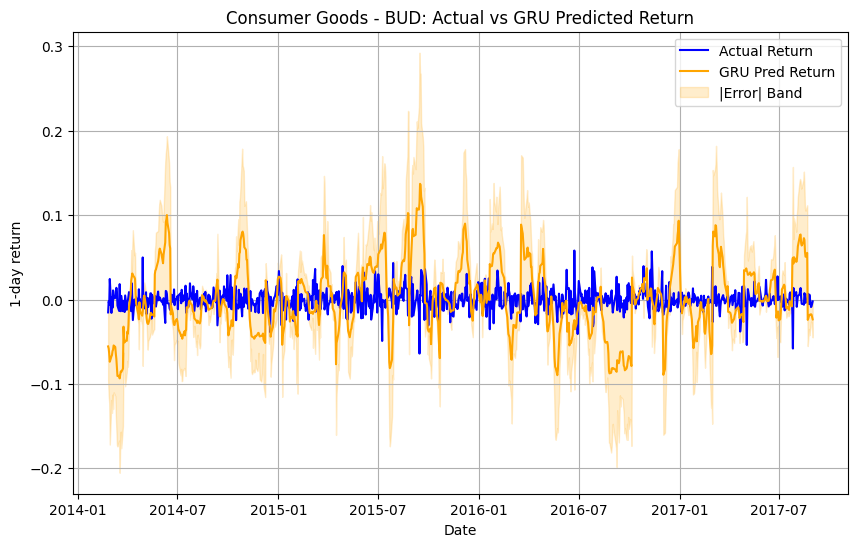

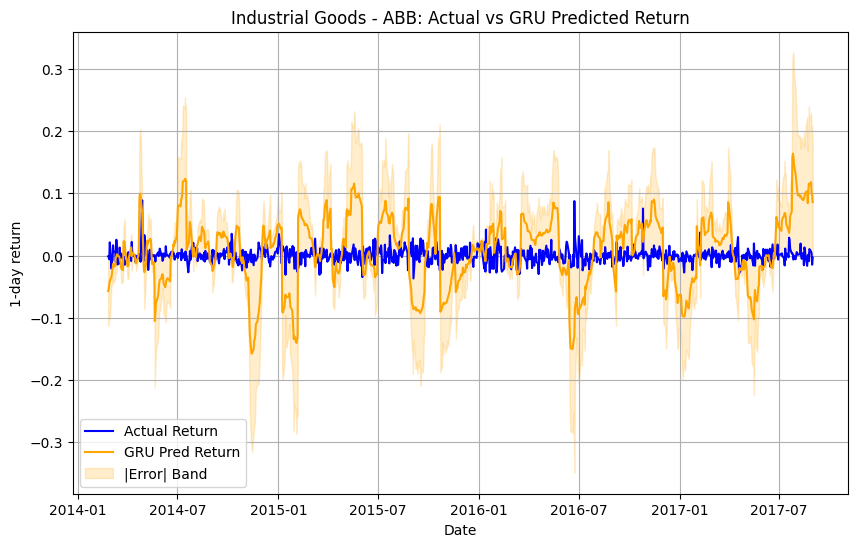

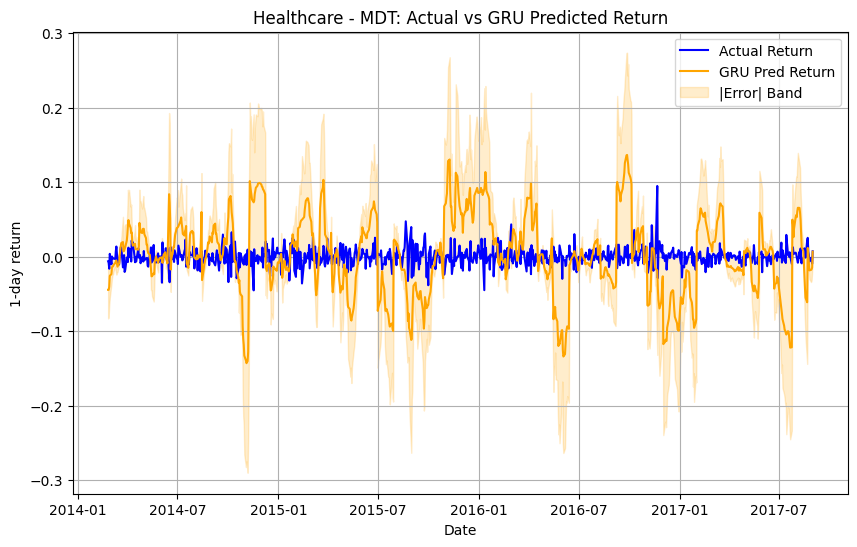

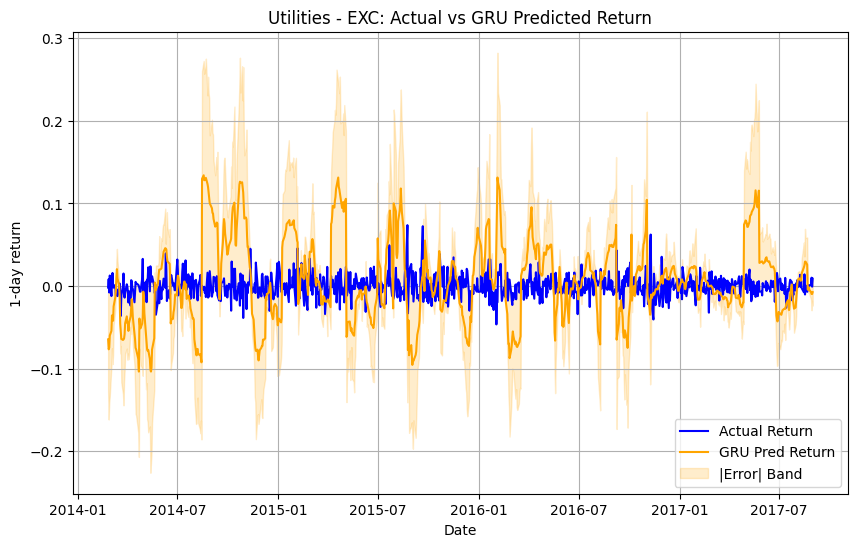

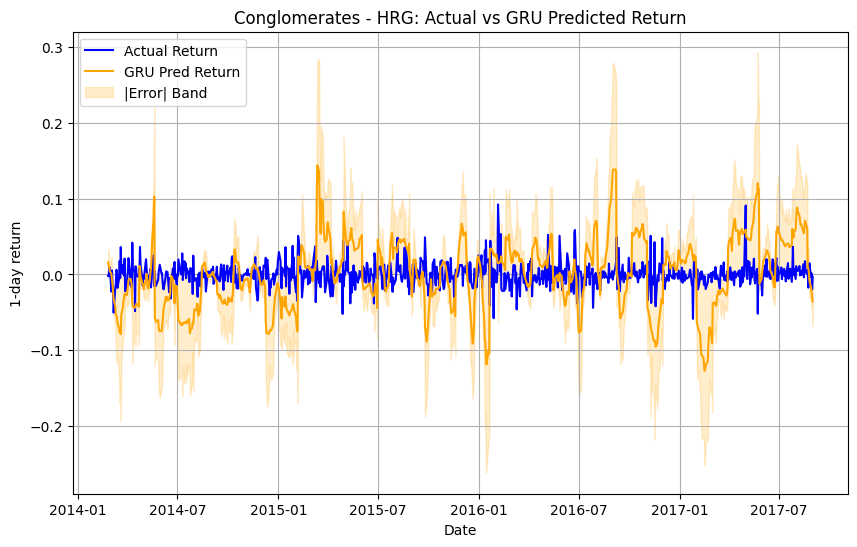

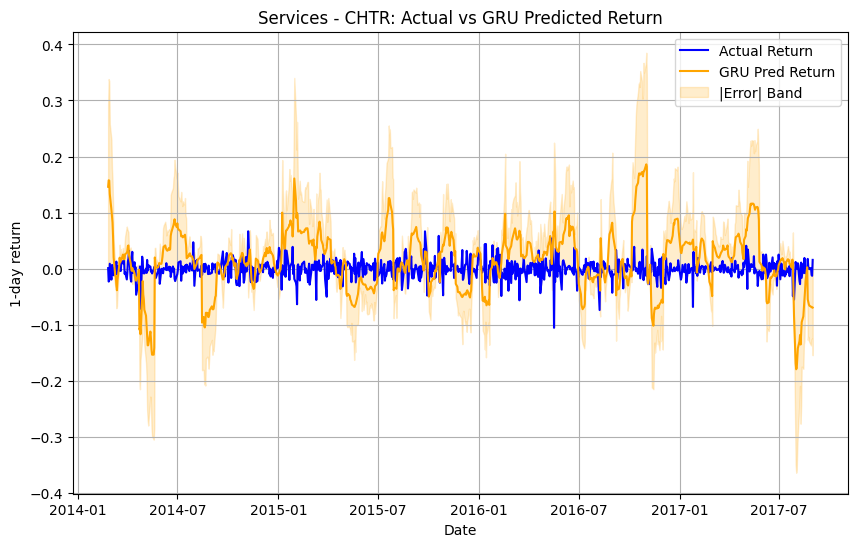

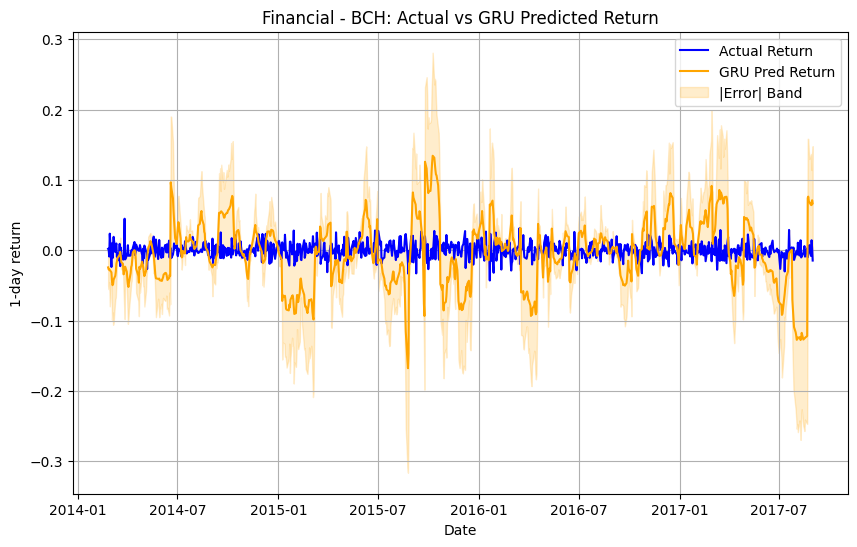

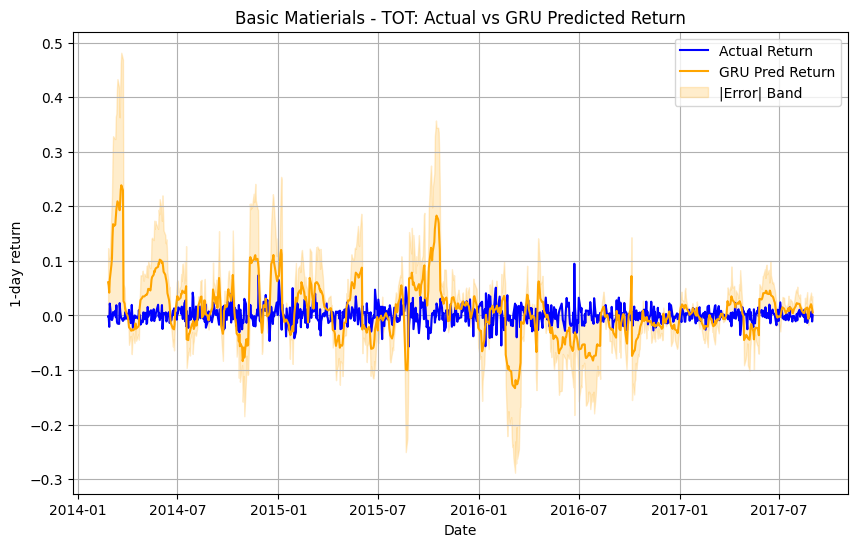

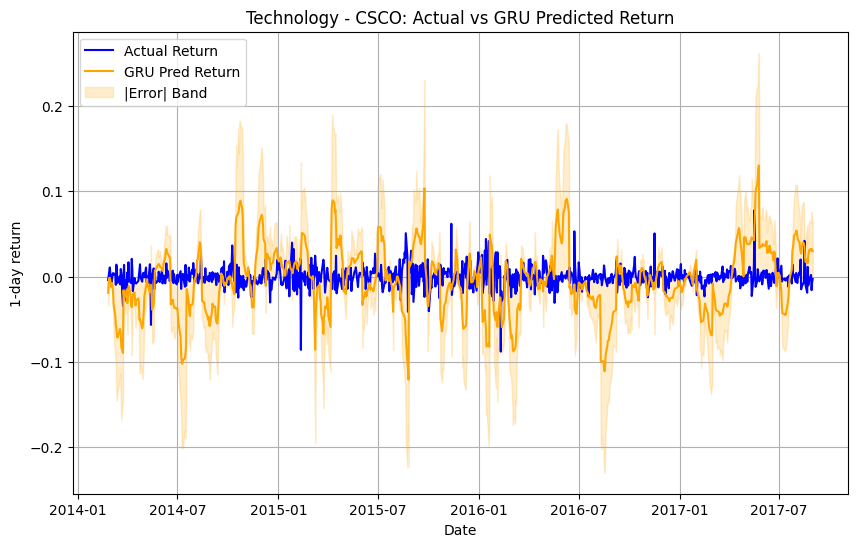

In [21]:
random.seed(42)
sector_ticker_map = {}
for sector in master_df['sector'].dropna().unique():
    tickers_in_sector = master_df.loc[master_df['sector'] == sector, 'ticker'].dropna().unique()
    if len(tickers_in_sector):
        sector_ticker_map[sector] = random.choice(tickers_in_sector)

for sector, ticker in sector_ticker_map.items():
    stock_data = master_df[master_df['ticker'] == ticker].dropna(subset=['gru_pred_ret_1d', 'ret_1d_meta'])
    if stock_data.empty:
        print(f"No valid data for sector {sector}, ticker {ticker}. Skipping.")
        continue
    stock_data = stock_data.sort_values('date')
    plt.figure(figsize=(10, 6))
    plt.plot(stock_data['date'], stock_data['ret_1d_meta'], label='Actual Return', color='blue')
    plt.plot(stock_data['date'], stock_data['gru_pred_ret_1d'], label='GRU Pred Return', color='orange')
    plt.fill_between(
        stock_data['date'],
        stock_data['gru_pred_ret_1d'] - stock_data['gru_abs_err_ret_1d'],
        stock_data['gru_pred_ret_1d'] + stock_data['gru_abs_err_ret_1d'],
        color='orange', alpha=0.2, label='|Error| Band'
    )
    plt.title(f"{sector} - {ticker}: Actual vs GRU Predicted Return")
    plt.xlabel("Date")
    plt.ylabel("1-day return")
    plt.legend()
    plt.grid()
    plt.show()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104220 entries, 0 to 104219
Data columns (total 68 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   date                  104220 non-null  datetime64[ns]
 1   open                  104220 non-null  float64       
 2   high                  104220 non-null  float64       
 3   low                   104220 non-null  float64       
 4   close                 104220 non-null  float64       
 5   adj close             104220 non-null  float64       
 6   volume                104220 non-null  float64       
 7   ticker                104220 non-null  object        
 8   text                  19297 non-null   object        
 9   sentiment             104220 non-null  float64       
 10  emotion_anger         104220 non-null  float64       
 11  emotion_disgust       104220 non-null  float64       
 12  emotion_fear          104220 non-null  float

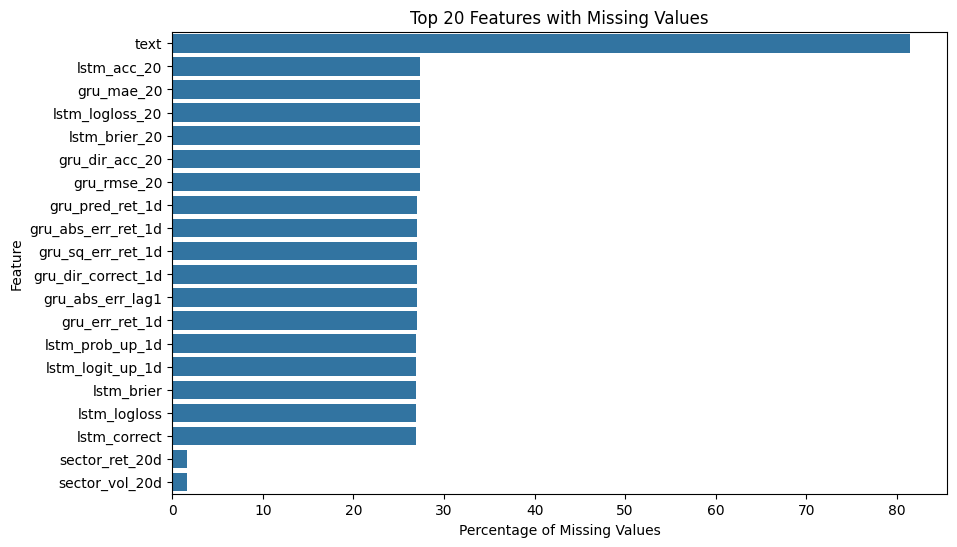

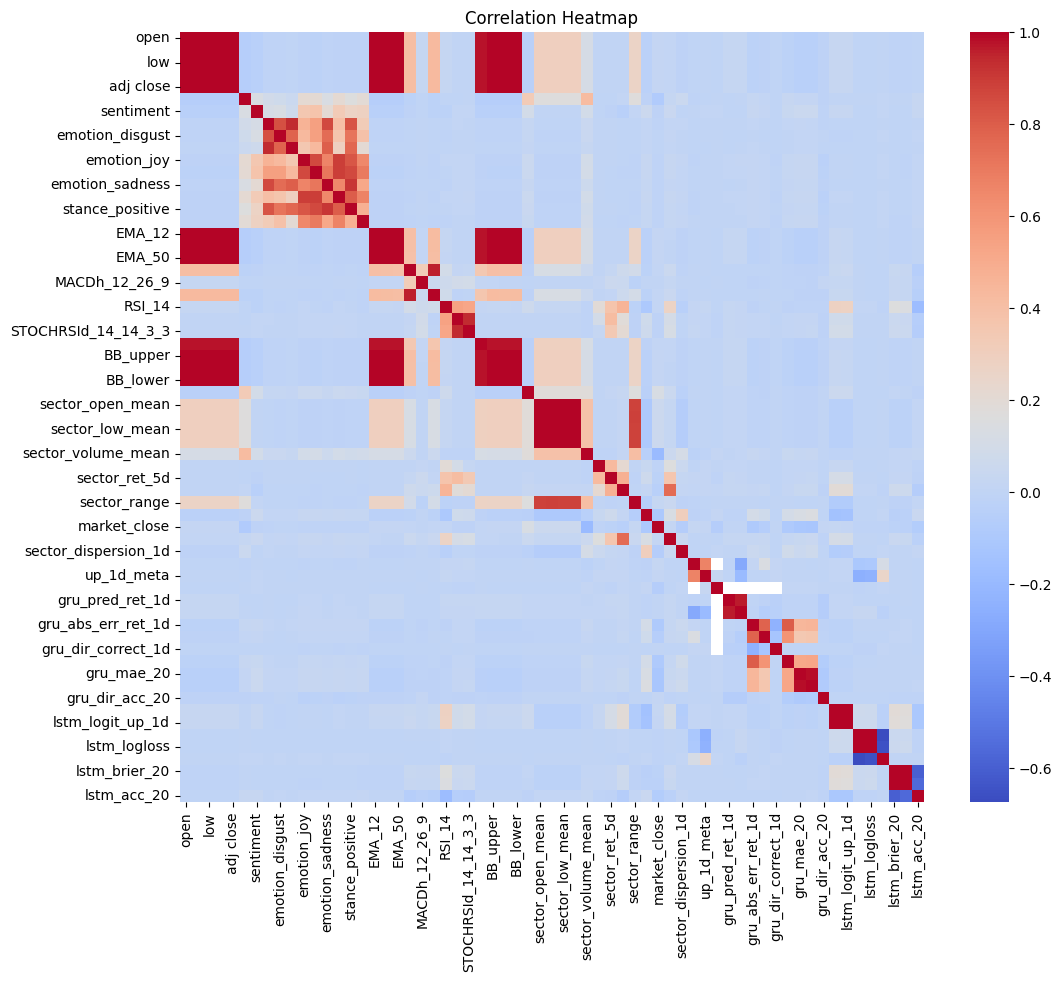


Highly Correlated Features (Threshold > 0.8):
high and open: 1.00
low and open: 1.00
low and high: 1.00
close and open: 1.00
close and high: 1.00
close and low: 1.00
adj close and open: 1.00
adj close and high: 1.00
adj close and low: 1.00
adj close and close: 1.00
emotion_disgust and emotion_anger: 0.84
emotion_fear and emotion_anger: 0.94
emotion_neutral and emotion_joy: 0.86
emotion_sadness and emotion_anger: 0.86
emotion_surprize and emotion_joy: 0.89
emotion_surprize and emotion_neutral: 0.89
stance_positive and emotion_anger: 0.83
stance_positive and emotion_joy: 0.82
stance_positive and emotion_neutral: 0.86
stance_positive and emotion_sadness: 0.91
stance_positive and emotion_surprize: 0.80
EMA_12 and open: 1.00
EMA_12 and high: 1.00
EMA_12 and low: 1.00
EMA_12 and close: 1.00
EMA_12 and adj close: 1.00
EMA_26 and open: 1.00
EMA_26 and high: 1.00
EMA_26 and low: 1.00
EMA_26 and close: 1.00
EMA_26 and adj close: 1.00
EMA_26 and EMA_12: 1.00
EMA_50 and open: 1.00
EMA_50 and high

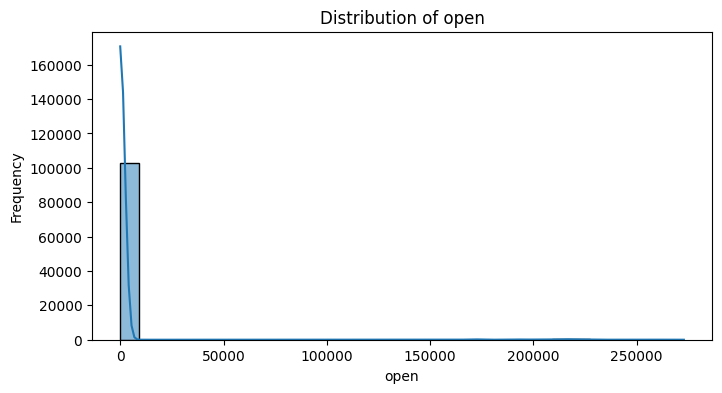

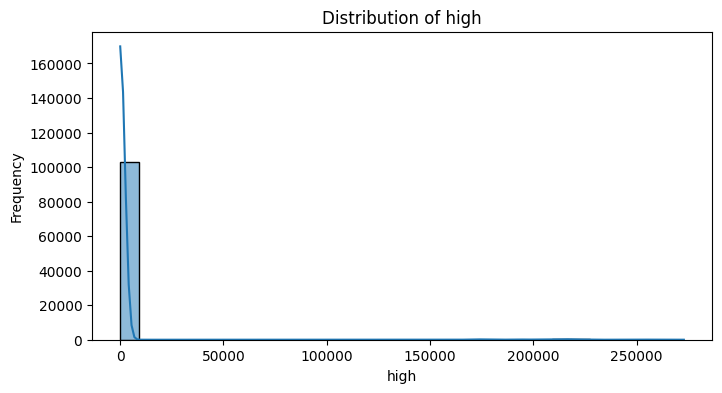

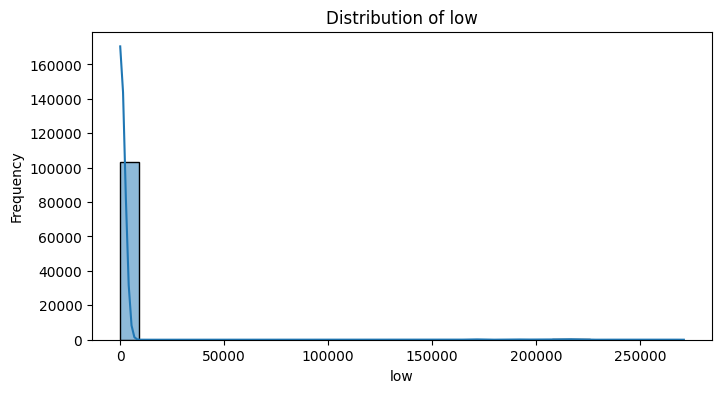

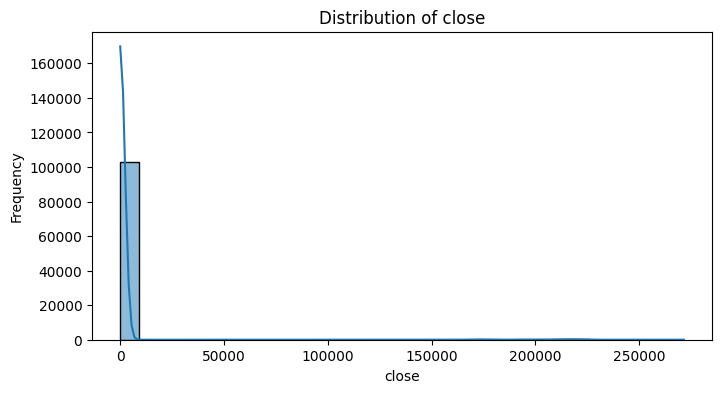

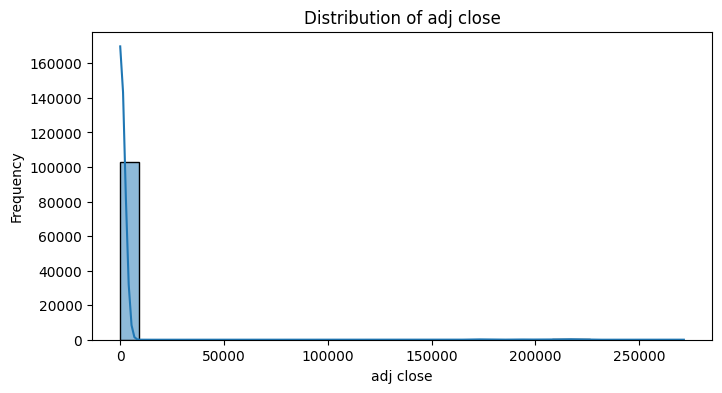

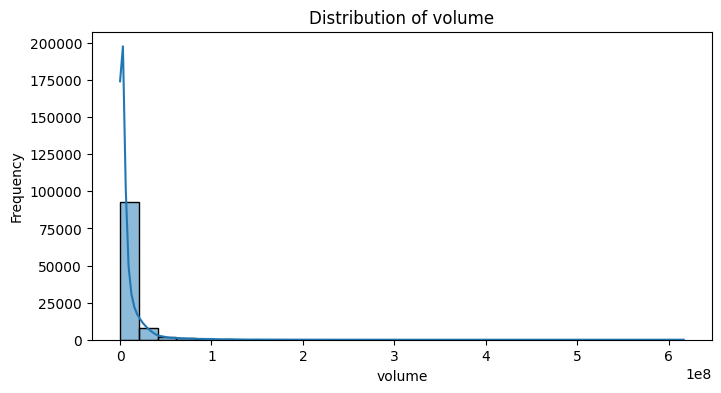

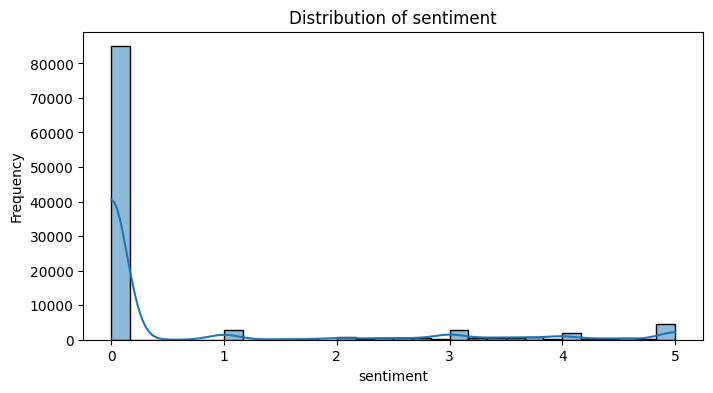

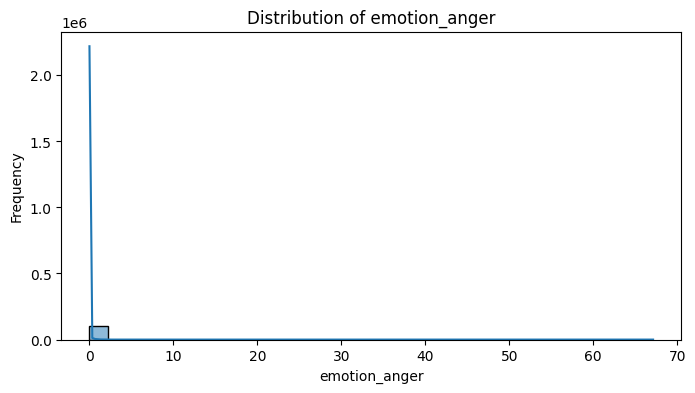

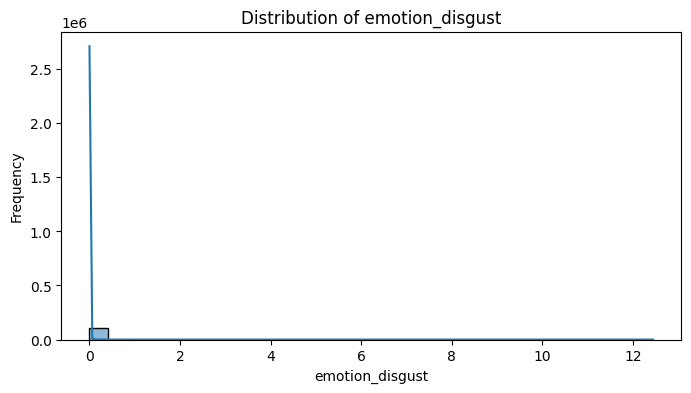

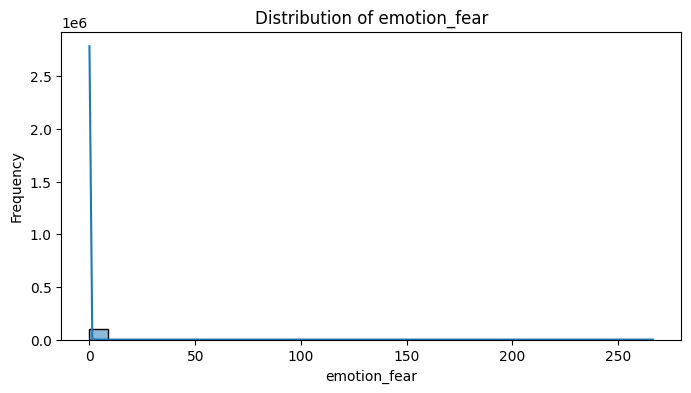

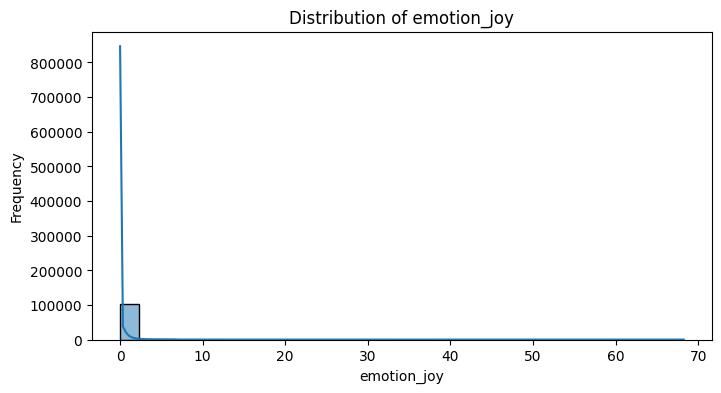

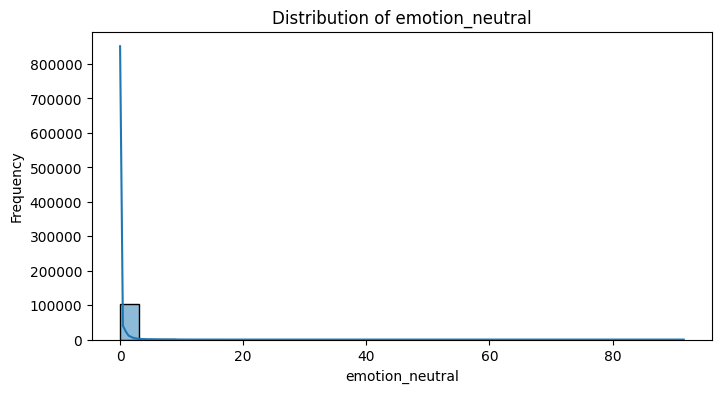

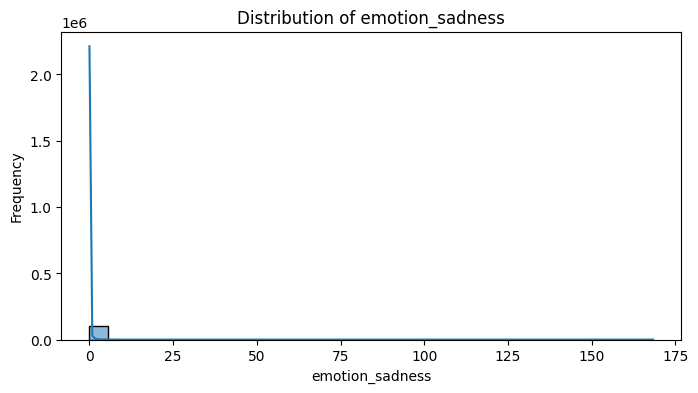

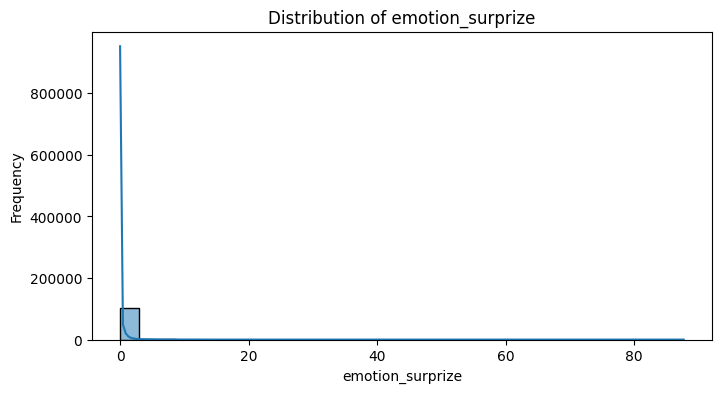

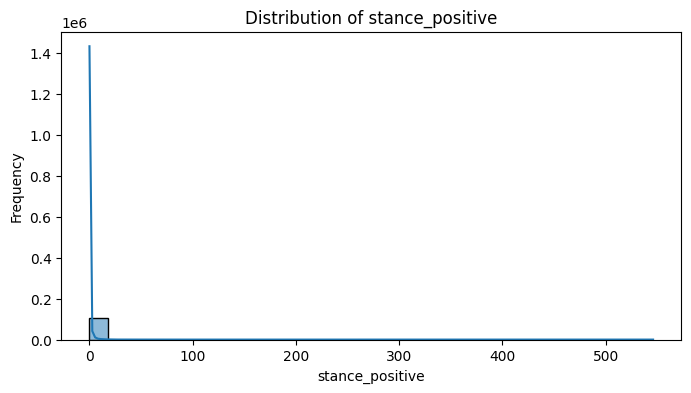

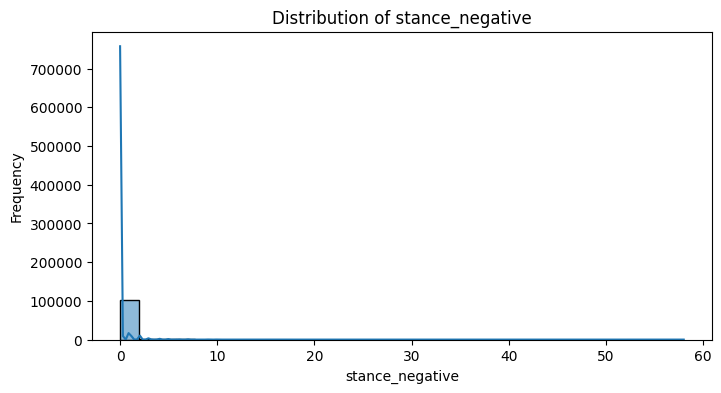

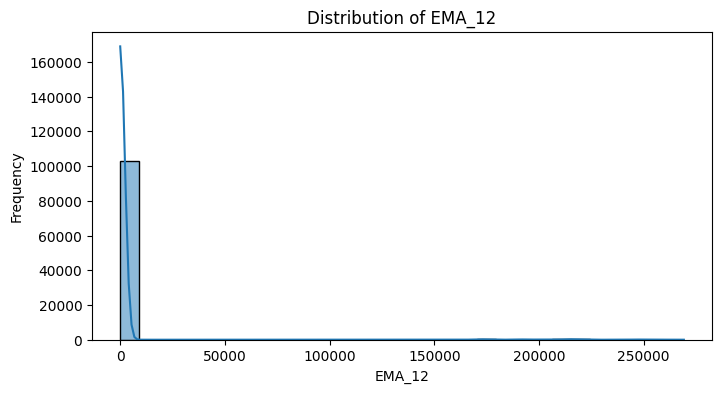

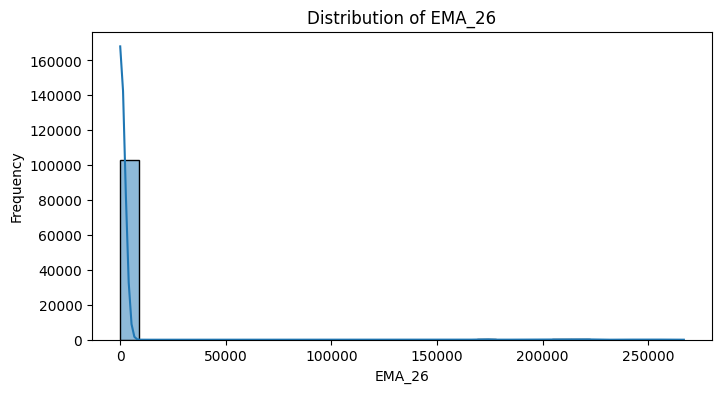

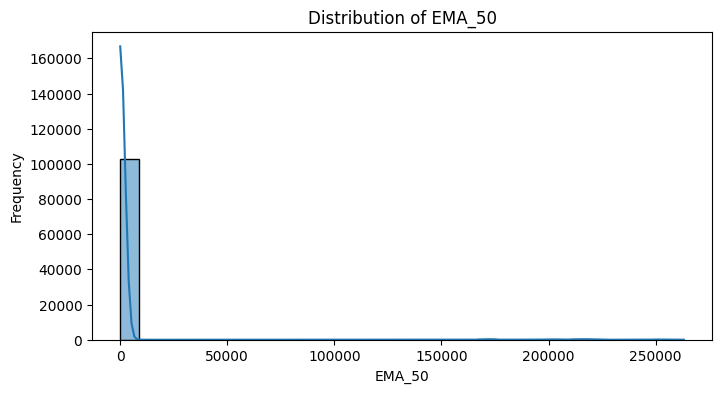

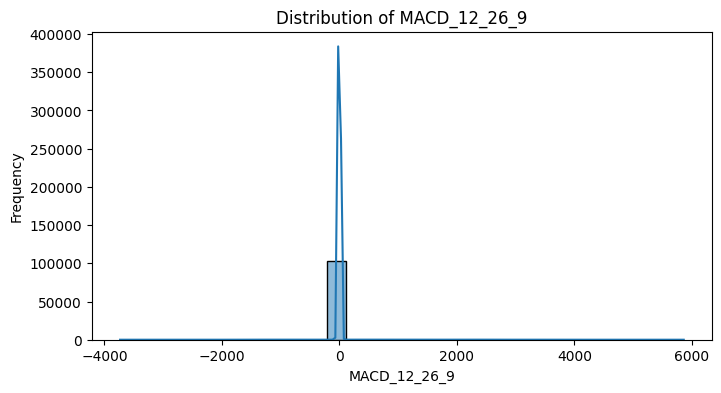

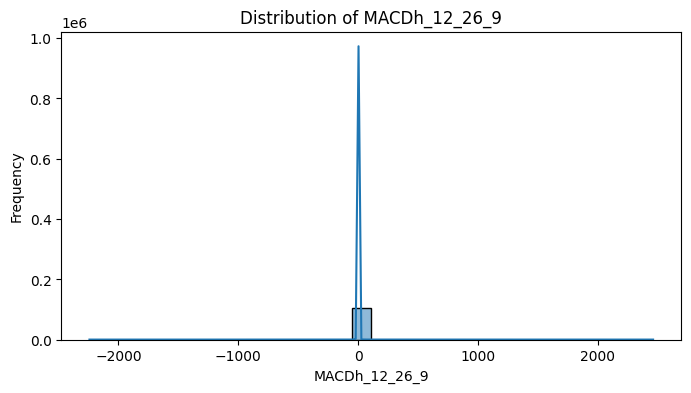

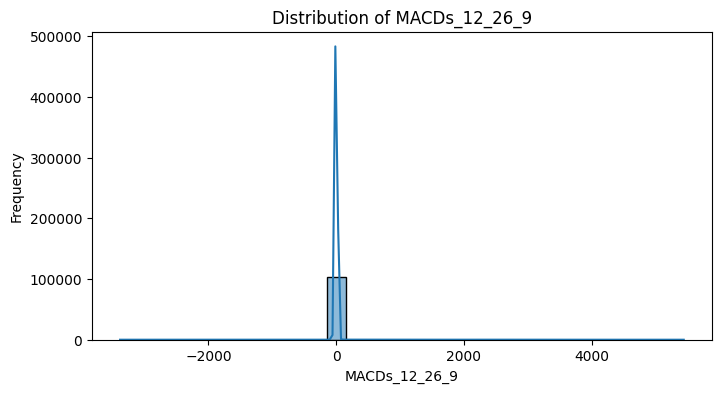

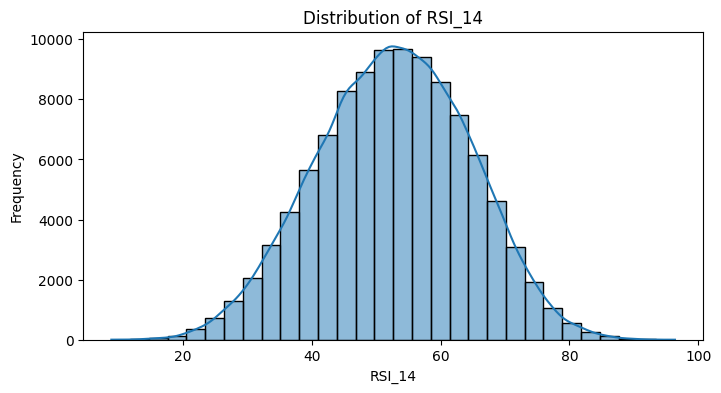

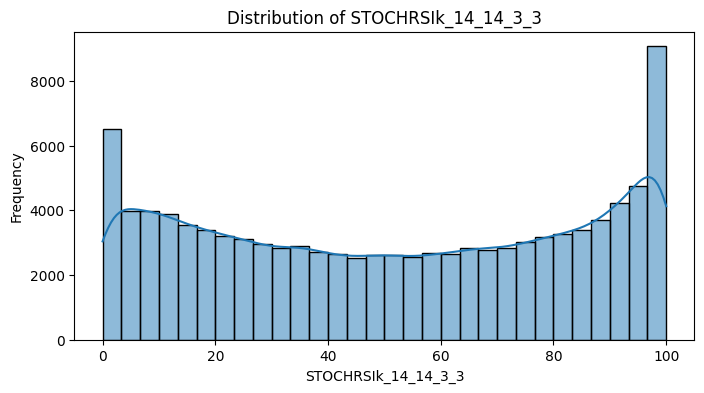

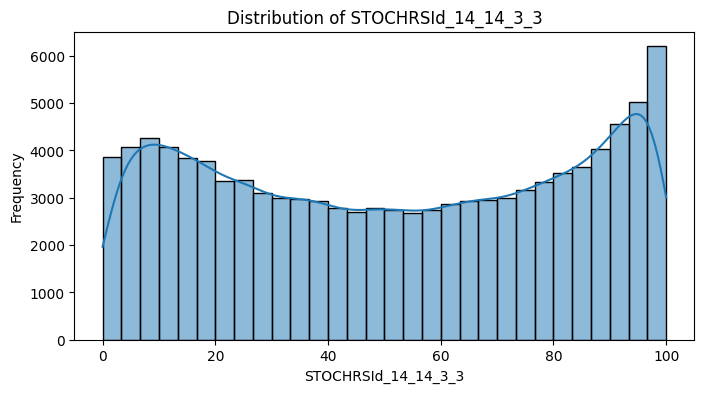

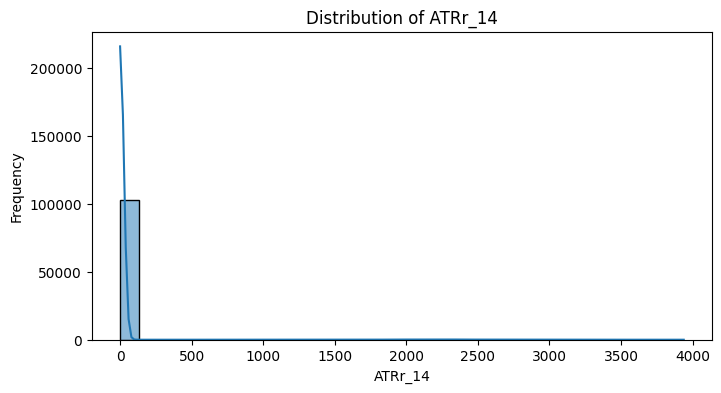

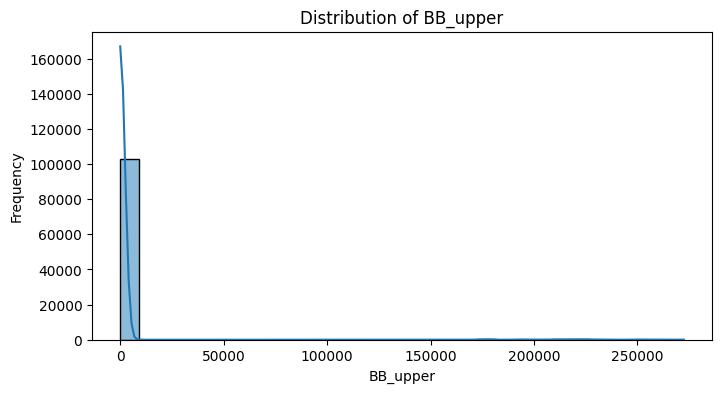

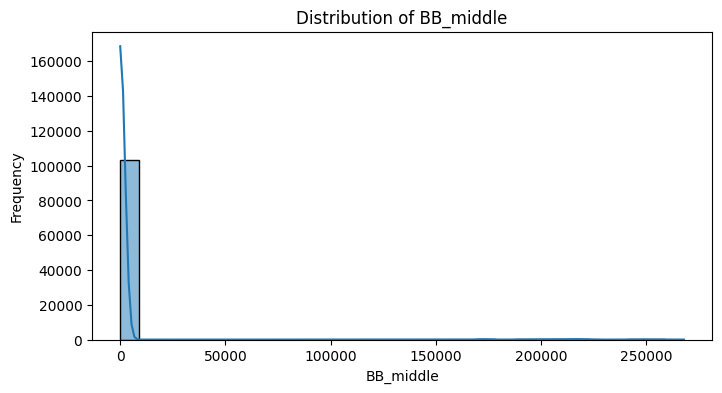

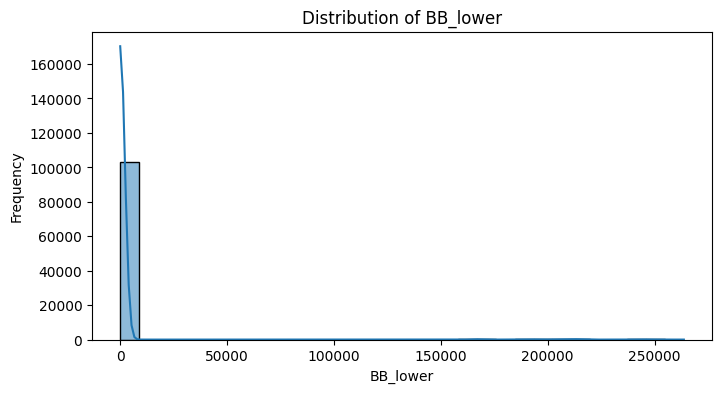

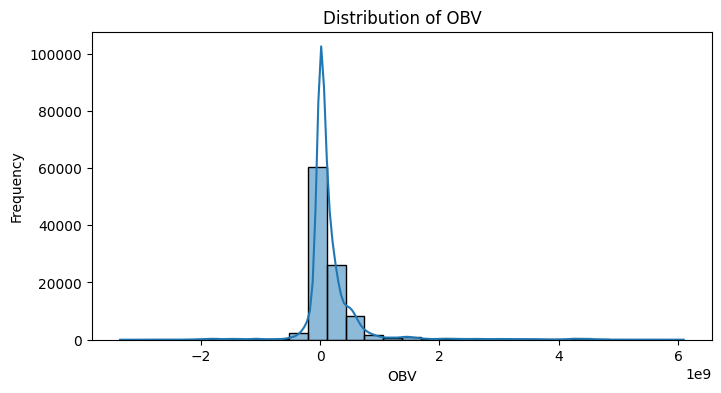

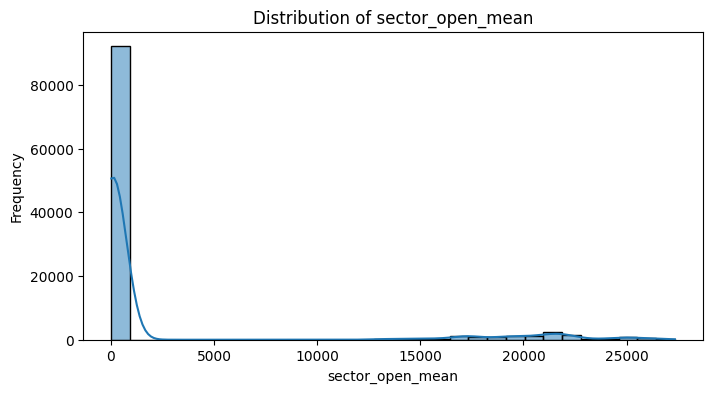

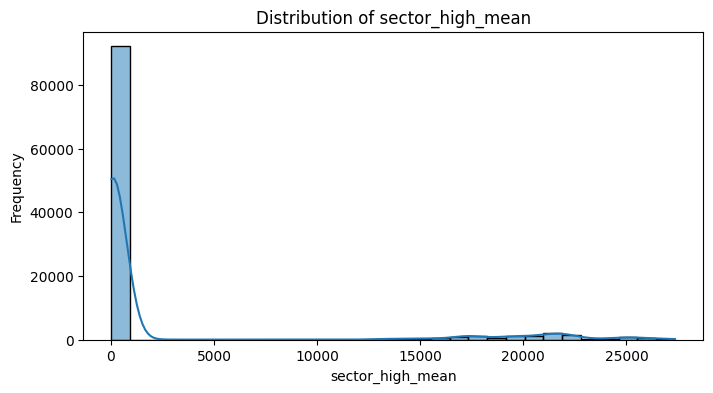

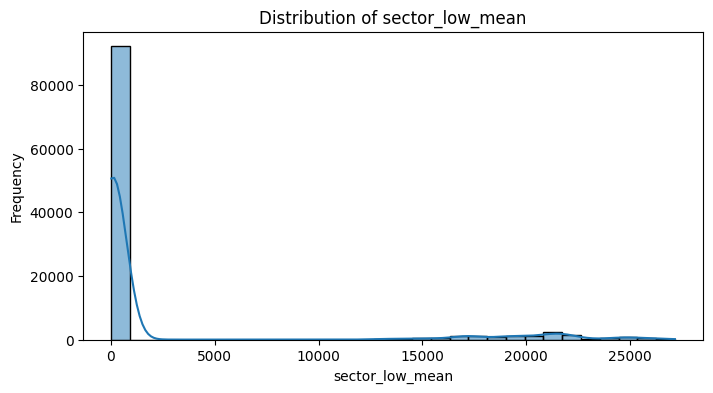

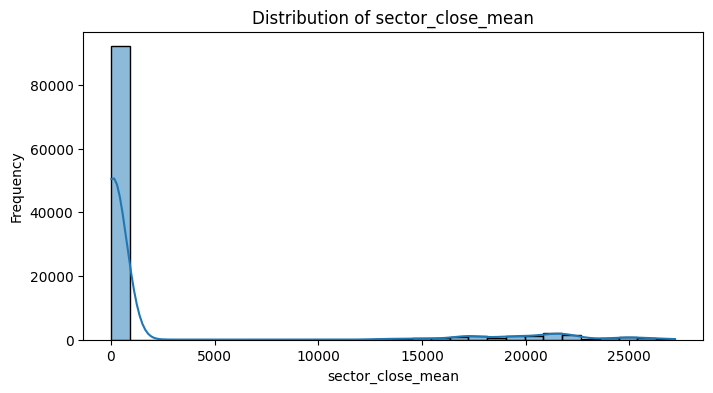

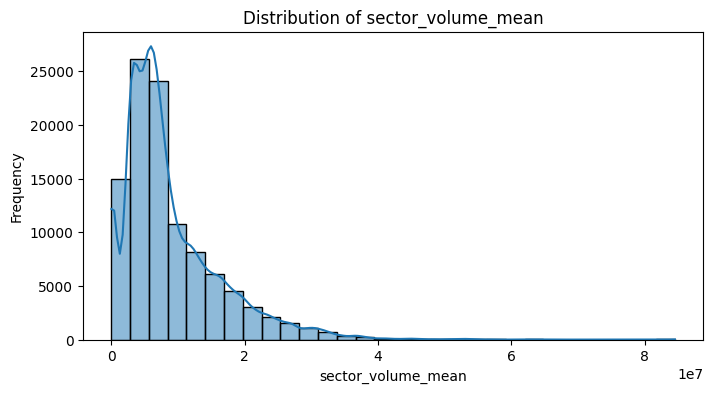

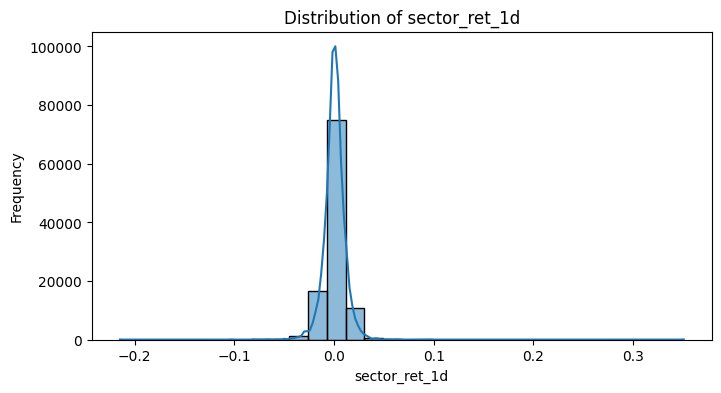

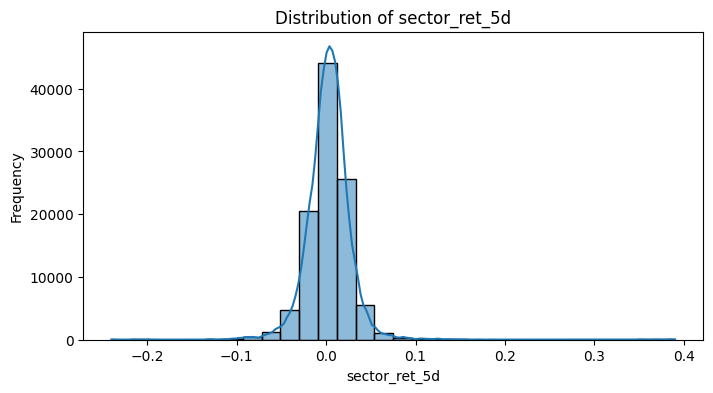

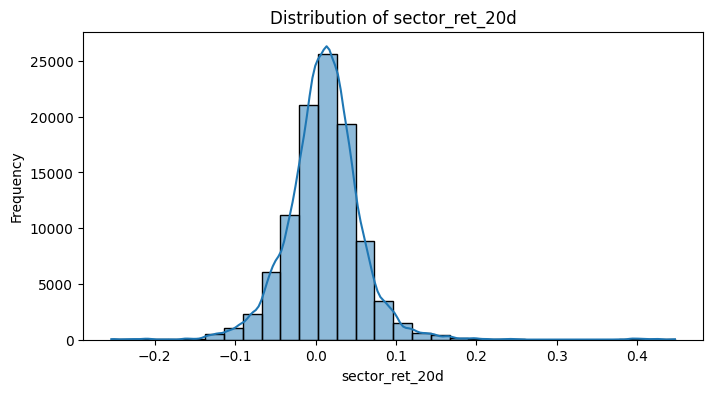

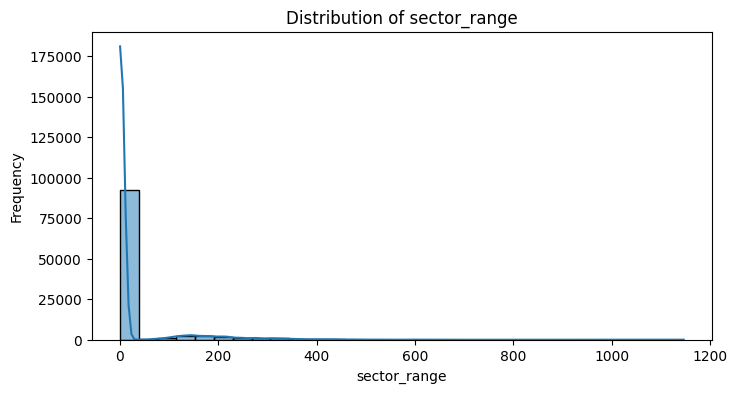

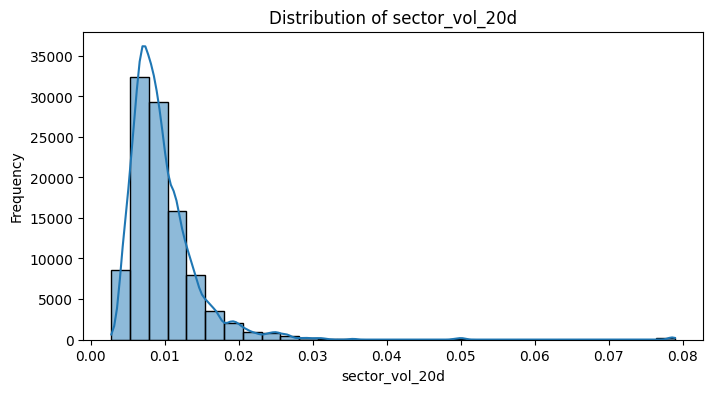

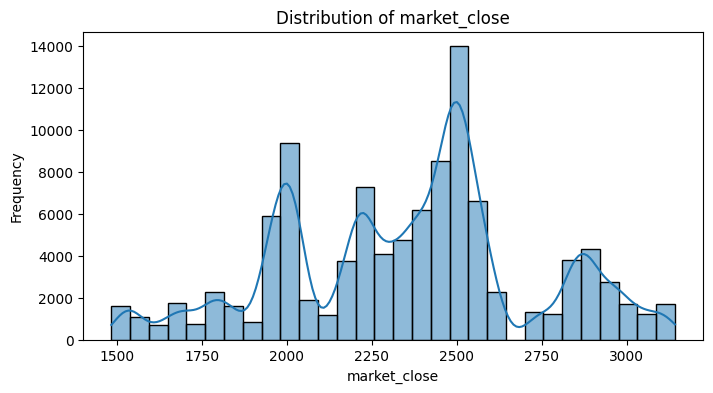

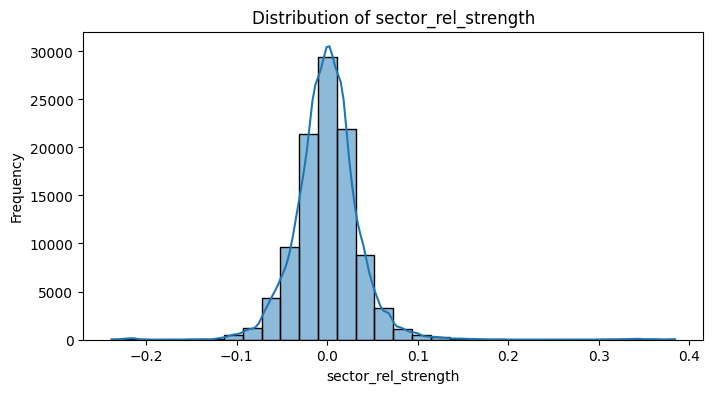

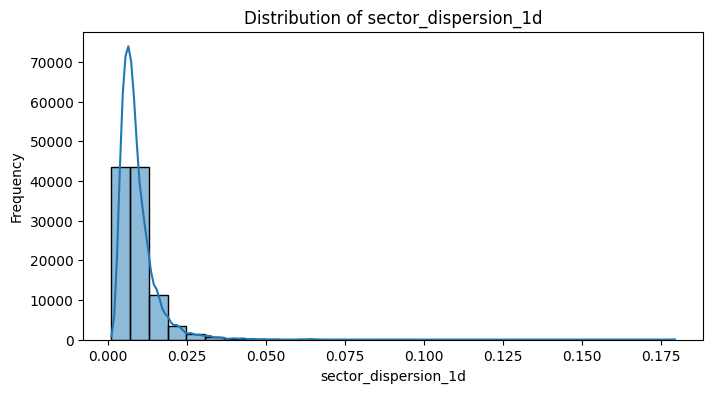

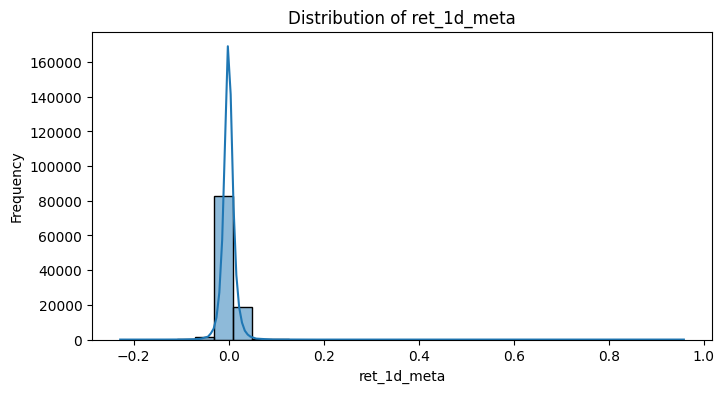

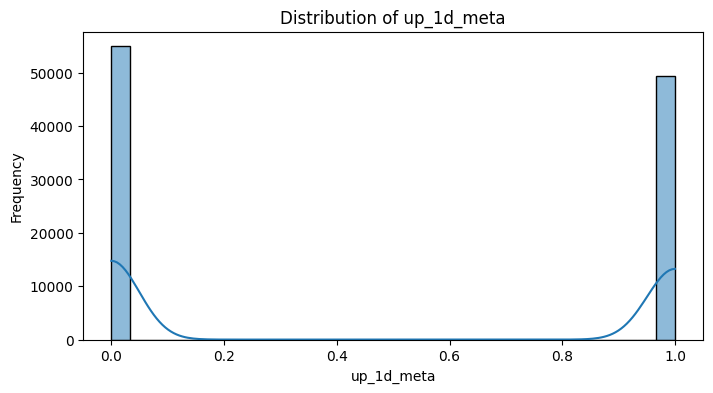

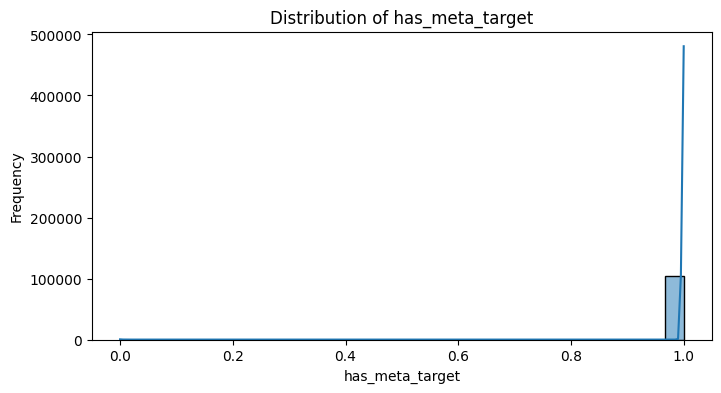

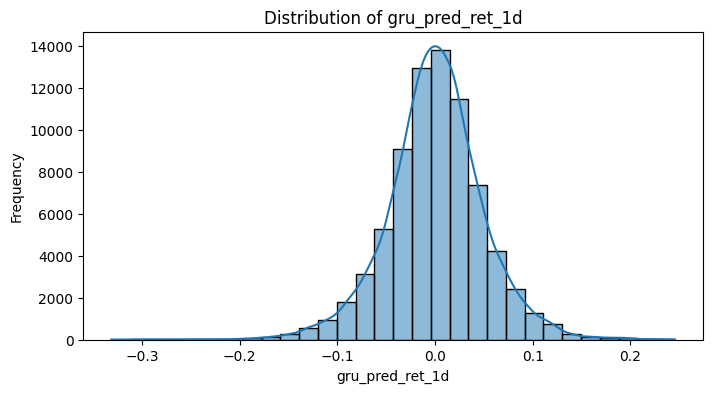

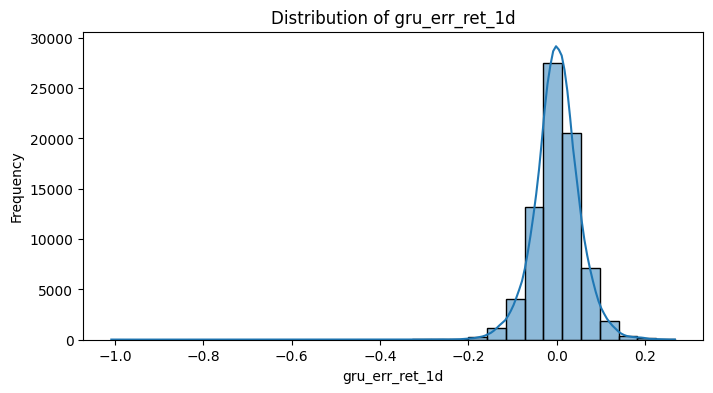

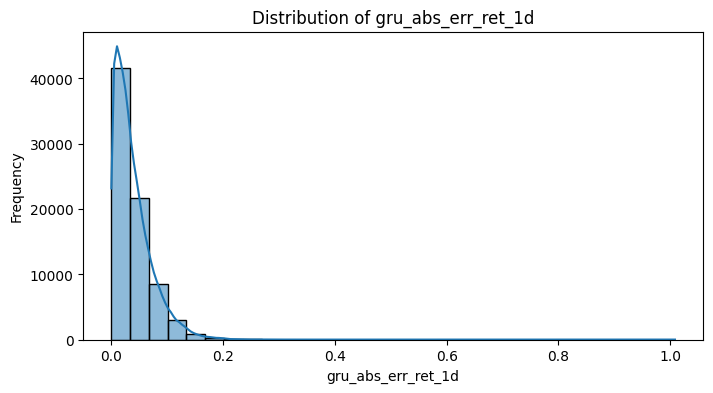

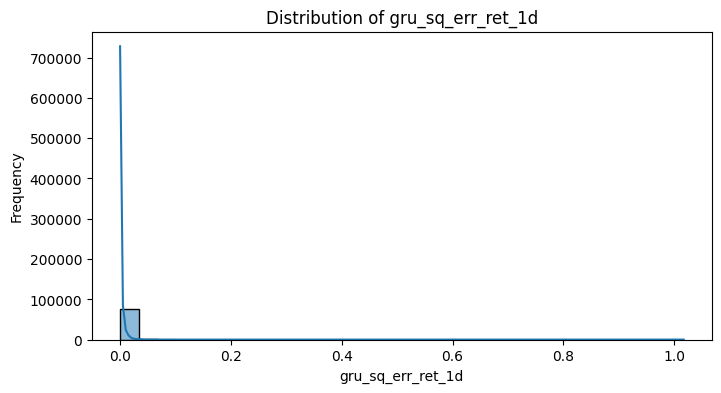

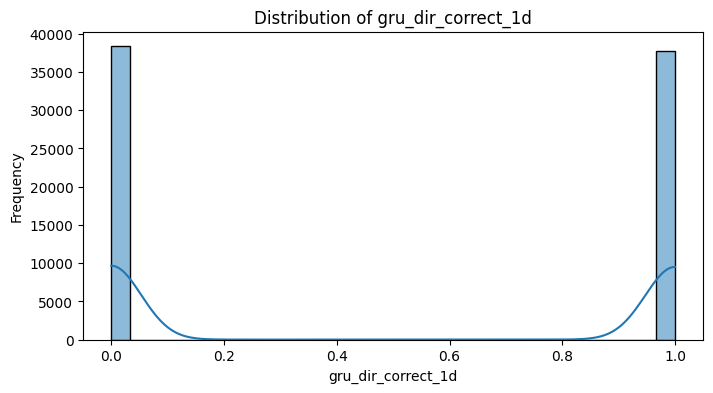

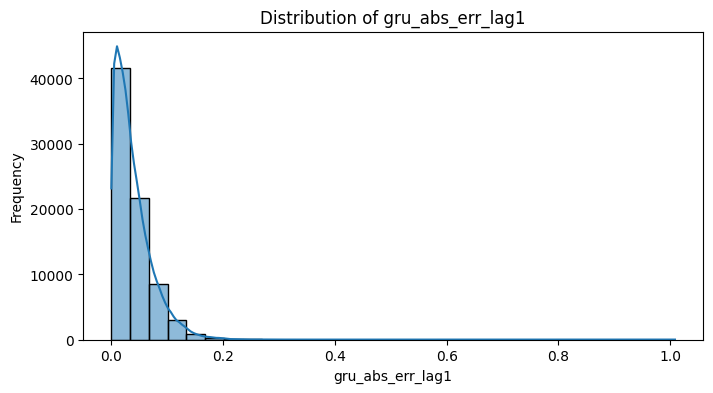

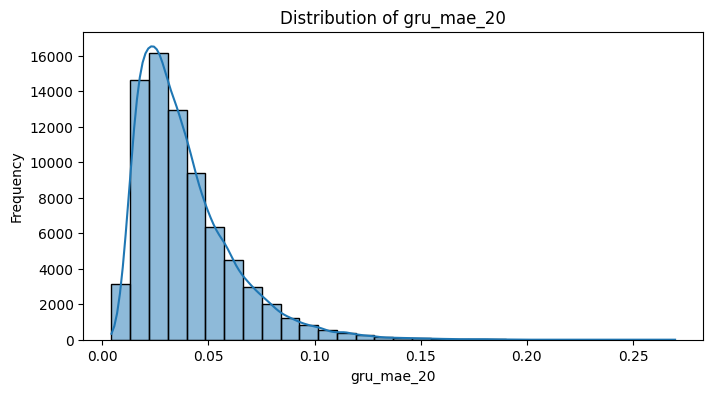

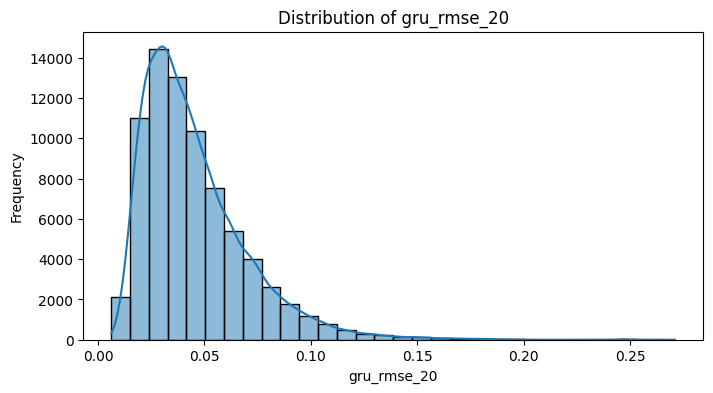

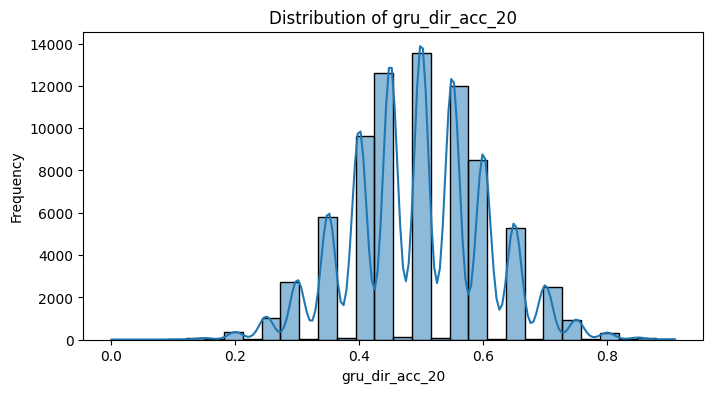

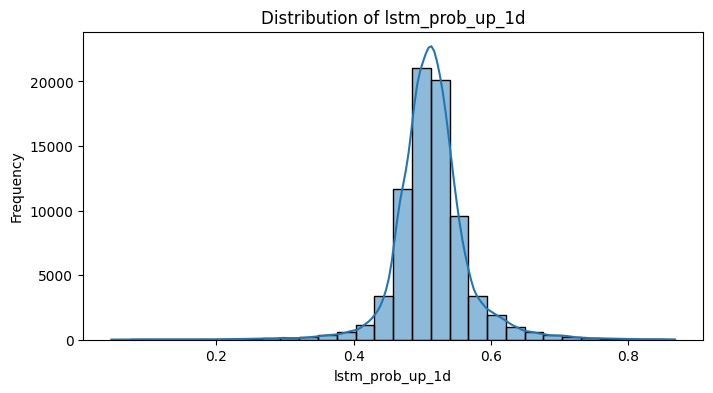

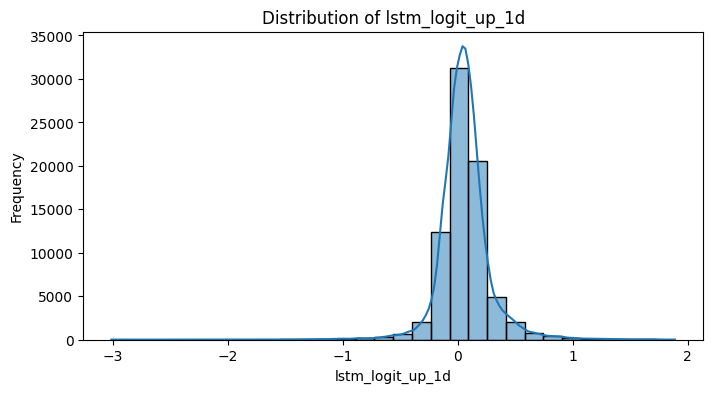

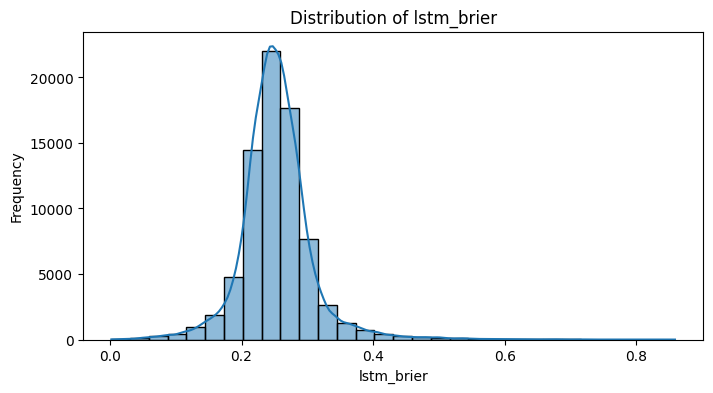

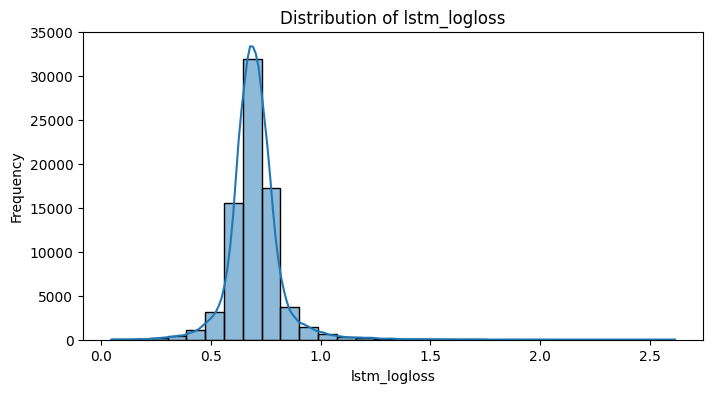

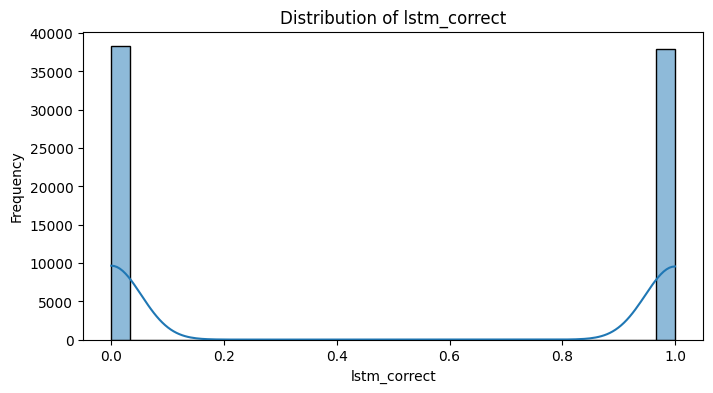

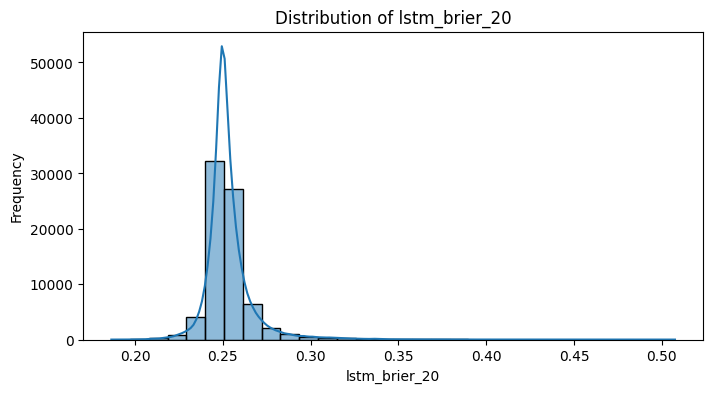

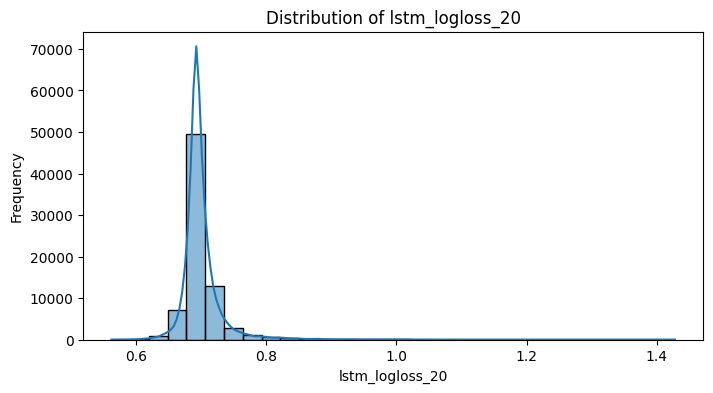

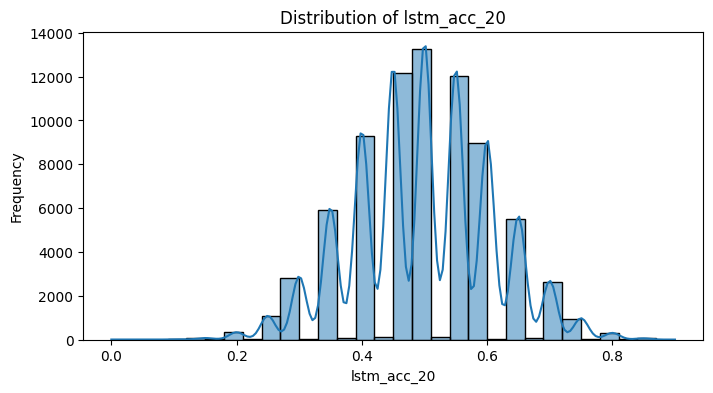

ValueError: Found input variables with inconsistent numbers of samples: [104220, 104132]

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

# Load the dataset
file_path = "stocknet-dataset/master_df_with_sector_and_meta_features.parquet"
df = pd.read_parquet(file_path)

# Display basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\nDataset Description:")
print(df.describe(include='all'))

# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Feature': missing_values.index, 'Missing Values': missing_values.values, 'Percentage': missing_percentage.values})
print("\nMissing Values:")
print(missing_df.sort_values(by='Percentage', ascending=False))

# Visualize missing values
plt.figure(figsize=(10, 6))
sns.barplot(x='Percentage', y='Feature', data=missing_df.sort_values(by='Percentage', ascending=False).head(20))
plt.title("Top 20 Features with Missing Values")
plt.xlabel("Percentage of Missing Values")
plt.ylabel("Feature")
plt.show()

# Correlation analysis
numerical_features = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_features].corr()

# Plot heatmap of correlations
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Identify highly correlated features
threshold = 0.8
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

print("\nHighly Correlated Features (Threshold > 0.8):")
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]}: {pair[2]:.2f}")

# Visualize distributions of numerical features
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()